# Trabalho de Visão Computacional — Classificação/Detecção de Imagens

Este notebook foi ampliado a partir do notebook original da equipe.

## Objetivos contemplados
- Utilizar **duas classes**.
- Validar a quantidade e a divisão das imagens entre **treino, validação e teste**.
- Utilizar **YOLOv5 customizada**.
- Comparar treinamentos com **20 e 40 épocas**.
- Apresentar métricas como **Precision, Recall e mAP**.
- Executar uma **YOLO pré-treinada** sem treinamento customizado para comparação.
- Criar uma **CNN do zero** com TensorFlow/Keras.
- Comparar as abordagens quanto a desempenho, tempo e facilidade de uso.
- Apresentar resultados e conclusão.

> **Importante:** a evidência de que a rotulagem foi feita no Make Sense IA não pode ser criada automaticamente pelo notebook. Se o enunciado exigir comprovação da ferramenta, insira uma captura de tela da rotulagem nesta seção ou no README do projeto.

## 1. Configuração do ambiente

A célula abaixo mantém o mesmo caminho-base utilizado no notebook original.  
Caso a pasta tenha sido movida no Google Drive, altere somente `BASE_PATH`.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path

BASE_PATH = Path('/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo')
YAML_PATH = BASE_PATH / 'classificar.yaml'
TEST_PATH = BASE_PATH / 'test'

print('BASE_PATH:', BASE_PATH)
print('YAML_PATH:', YAML_PATH)
print('TEST_PATH:', TEST_PATH)
print('YAML existe?', YAML_PATH.exists())
print('Pasta de teste existe?', TEST_PATH.exists())

Mounted at /content/drive
BASE_PATH: /content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo
YAML_PATH: /content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/classificar.yaml
TEST_PATH: /content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/test
YAML existe? True
Pasta de teste existe? True


## 2. Instalação do YOLOv5

In [2]:
import os

if not Path('/content/yolov5').exists():
    !git clone https://github.com/ultralytics/yolov5.git /content/yolov5
else:
    print('YOLOv5 já clonado.')

!pip -q install -r /content/yolov5/requirements.txt
!pip -q install pyyaml pandas matplotlib seaborn scikit-learn tensorflow

Cloning into '/content/yolov5'...
remote: Enumerating objects: 18770, done.
remote: Counting objects: 100% (327/327), done.
remote: Compressing objects: 100% (199/199), done.
remote: Total 18770 (delta 264), reused 128 (delta 128), pack-reused 18443 (from 5)
Receiving objects: 100% (18770/18770), 17.83 MiB | 17.91 MiB/s, done.
Resolving deltas: 100% (12769/12769), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 96.5/96.5 kB 9.2 MB/s eta 0:00:00


## 3. Inspeção do arquivo `classificar.yaml`

Esta etapa documenta as classes e os diretórios usados pelo YOLO.

In [3]:
import yaml
import pprint

# Carregar o arquivo yaml original
with open(YAML_PATH, 'r', encoding='utf-8') as f:
    data_cfg = yaml.safe_load(f)

antigo_prefixo = '/content/drive/MyDrive'
novo_prefixo = '/content/drive/MyDrive'

# Substituir os caminhos se existirem no dicionário
for chave in ['train', 'val', 'test']:
    if chave in data_cfg and isinstance(data_cfg[chave], str):
        if data_cfg[chave].startswith(antigo_prefixo) and not data_cfg[chave].startswith(novo_prefixo):
            data_cfg[chave] = data_cfg[chave].replace(antigo_prefixo, novo_prefixo)

# Salvar as alterações de volta no arquivo classificar.yaml
with open(YAML_PATH, 'w', encoding='utf-8') as f:
    yaml.dump(data_cfg, f, default_flow_style=False, allow_unicode=True)

print("Configuração do YAML atualizada:")
pprint.pp(data_cfg)

names = data_cfg.get('names', [])
if isinstance(names, dict):
    names = [names[k] for k in sorted(names)]

print('\nClasses encontradas:', names)
print('Quantidade de classes:', len(names))

assert len(names) == 2, f'O trabalho exige 2 classes, mas o YAML contém {len(names)}.'

Configuração do YAML atualizada:
{'names': {0: 'Copo', 1: 'Taca'},
 'train': '/content/drive/MyDrive/Cap 1 - O despertar da Rede '
          'Neural/RedeNeuralYolo/images/train',
 'val': '/content/drive/MyDrive/Cap 1 - O despertar da Rede '
        'Neural/RedeNeuralYolo/images/val'}

Classes encontradas: ['Copo', 'Taca']
Quantidade de classes: 2


## 4. Validação do dataset

O enunciado solicita, para cada classe:

- **32 imagens para treino**
- **4 imagens para validação**
- **4 imagens para teste**
- Total mínimo: **40 imagens por classe**

A célula a seguir tenta localizar os diretórios informados pelo YAML e contabiliza as anotações YOLO por classe.

> Como uma imagem pode conter mais de um objeto, a contagem de **imagens contendo cada classe** é mais relevante do que apenas contar caixas delimitadoras.

In [4]:
from collections import defaultdict
from pathlib import Path
import os

IMG_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}

def resolve_cfg_path(value):
    if value is None:
        return None
    p = Path(str(value))
    if p.is_absolute():
        return p
    yaml_root = Path(data_cfg.get('path', YAML_PATH.parent))
    if not yaml_root.is_absolute():
        yaml_root = YAML_PATH.parent / yaml_root
    return (yaml_root / p).resolve()

def labels_dir_from_images_dir(images_dir):
    s = str(images_dir)
    if '/images/' in s:
        return Path(s.replace('/images/', '/labels/'))
    if s.endswith('/images'):
        return Path(s[:-7] + '/labels')
    candidate = images_dir.parent / 'labels' / images_dir.name
    if candidate.exists():
        return candidate
    return images_dir

def count_split(split_name):
    images_dir = resolve_cfg_path(data_cfg.get(split_name))
    if images_dir is None:
        return None

    # YAML pode apontar para um arquivo .txt com lista de imagens
    if images_dir.is_file() and images_dir.suffix == '.txt':
        image_files = [Path(x.strip()) for x in images_dir.read_text().splitlines() if x.strip()]
    else:
        image_files = [p for p in images_dir.rglob('*') if p.suffix.lower() in IMG_EXTS]

    class_images = defaultdict(set)
    class_boxes = defaultdict(int)
    unlabeled = []

    for img in image_files:
        # tenta encontrar label correspondente seguindo estrutura YOLO padrão
        img_str = str(img)
        if '/images/' in img_str:
            label_path = Path(img_str.replace('/images/', '/labels/')).with_suffix('.txt')
        else:
            label_path = img.with_suffix('.txt')
            if not label_path.exists():
                alt = img.parent.parent / 'labels' / img.parent.name / (img.stem + '.txt')
                if alt.exists():
                    label_path = alt

        if not label_path.exists():
            unlabeled.append(img)
            continue

        for line in label_path.read_text(encoding='utf-8', errors='ignore').splitlines():
            parts = line.split()
            if not parts:
                continue
            cls = int(float(parts[0]))
            class_images[cls].add(str(img))
            class_boxes[cls] += 1

    return {
        'split': split_name,
        'images_dir': str(images_dir),
        'total_images': len(image_files),
        'class_images': {k: len(v) for k, v in class_images.items()},
        'class_boxes': dict(class_boxes),
        'unlabeled': len(unlabeled)
    }

dataset_report = []
for split in ['train', 'val', 'test']:
    result = count_split(split)
    if result:
        dataset_report.append(result)

dataset_report

[{'split': 'train',
  'images_dir': '/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/images/train',
  'total_images': 72,
  'class_images': {1: 36, 0: 36},
  'class_boxes': {1: 36, 0: 36},
  'unlabeled': 0},
 {'split': 'val',
  'images_dir': '/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/images/val',
  'total_images': 8,
  'class_images': {1: 4, 0: 4},
  'class_boxes': {1: 4, 0: 4},
  'unlabeled': 0}]

In [5]:
import pandas as pd

rows = []
for r in dataset_report:
    row = {
        'divisao': r['split'],
        'total_imagens': r['total_images'],
        'sem_rotulo': r['unlabeled']
    }
    for idx, class_name in enumerate(names):
        row[f'imagens_{class_name}'] = r['class_images'].get(idx, 0)
        row[f'boxes_{class_name}'] = r['class_boxes'].get(idx, 0)
    rows.append(row)

df_dataset = pd.DataFrame(rows)
display(df_dataset)

print('\nCritério esperado por classe: treino >= 32, validação >= 4 e teste >= 4.')
print('Se o YAML não possuir a chave test, a pasta TEST_PATH será usada posteriormente para inferência,')
print('mas recomenda-se documentar explicitamente as 4 imagens de teste de cada classe.')

,divisao,total_imagens,sem_rotulo,imagens_Copo,boxes_Copo,imagens_Taca,boxes_Taca
0,train,72,0,36,36,36,36
1,val,8,0,4,4,4,4



Critério esperado por classe: treino >= 32, validação >= 4 e teste >= 4.
Se o YAML não possuir a chave test, a pasta TEST_PATH será usada posteriormente para inferência,
mas recomenda-se documentar explicitamente as 4 imagens de teste de cada classe.


## 5. Evidência da rotulagem

O código abaixo apenas confirma a existência de arquivos de anotação YOLO (`.txt`).

**Inclua manualmente aqui ou no README uma captura de tela do Make Sense IA**, caso essa evidência faça parte dos critérios de avaliação.

In [6]:
label_files = list(BASE_PATH.rglob('*.txt'))
print(f'Arquivos .txt encontrados abaixo de BASE_PATH: {len(label_files)}')
for p in label_files[:20]:
    print(p)

Arquivos .txt encontrados abaixo de BASE_PATH: 80
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4388.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4463.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4474.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4478.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4391.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4509.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4427.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4471.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/labels/train/IMG_4458.txt
/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/R

# PARTE A — YOLO CUSTOMIZADA

## 6. Treinamento com 20 épocas

Usamos `yolov5s.pt` como ponto de partida (transferência de aprendizado), mas o modelo é treinado com as classes da equipe.

In [7]:
import time, subprocess, shlex

RUNS_DIR = '/content/yolov5/runs/train'

def run_command(cmd):
    print(cmd)
    inicio = time.perf_counter()
    proc = subprocess.run(cmd, shell=True, text=True)
    fim = time.perf_counter()
    if proc.returncode != 0:
        raise RuntimeError(f'Comando falhou com código {proc.returncode}')
    return fim - inicio

cmd20 = (
    f'python /content/yolov5/train.py '
    f'--data "{YAML_PATH}" '
    f'--weights yolov5s.pt '
    f'--img 640 '
    f'--epochs 20 '
    f'--name experimento_20_epocas '
    f'--exist-ok'
)

tempo_treino_20 = run_command(cmd20)
print(f'Tempo de treinamento (20 épocas): {tempo_treino_20:.2f} s')

python /content/yolov5/train.py --data "/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/classificar.yaml" --weights yolov5s.pt --img 640 --epochs 20 --name experimento_20_epocas --exist-ok
Tempo de treinamento (20 épocas): 1068.22 s


## 7. Validação do modelo de 20 épocas

In [8]:
WEIGHTS_20 = '/content/yolov5/runs/train/experimento_20_epocas/weights/best.pt'

cmd_val_20 = (
    f'python /content/yolov5/val.py '
    f'--weights "{WEIGHTS_20}" '
    f'--data "{YAML_PATH}" '
    f'--img 640 '
    f'--name validacao_20_epocas '
    f'--exist-ok'
)

tempo_val_20 = run_command(cmd_val_20)
print(f'Tempo de validação (20 épocas): {tempo_val_20:.2f} s')

python /content/yolov5/val.py --weights "/content/yolov5/runs/train/experimento_20_epocas/weights/best.pt" --data "/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/classificar.yaml" --img 640 --name validacao_20_epocas --exist-ok
Tempo de validação (20 épocas): 19.50 s


## 8. Treinamento com 40 épocas

Este experimento mantém os mesmos parâmetros, alterando somente o número de épocas.

In [9]:
cmd40 = (
    f'python /content/yolov5/train.py '
    f'--data "{YAML_PATH}" '
    f'--weights yolov5s.pt '
    f'--img 640 '
    f'--epochs 40 '
    f'--name experimento_40_epocas '
    f'--exist-ok'
)

tempo_treino_40 = run_command(cmd40)
print(f'Tempo de treinamento (40 épocas): {tempo_treino_40:.2f} s')

python /content/yolov5/train.py --data "/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/classificar.yaml" --weights yolov5s.pt --img 640 --epochs 40 --name experimento_40_epocas --exist-ok
Tempo de treinamento (40 épocas): 1987.35 s


## 9. Validação do modelo de 40 épocas

In [10]:
WEIGHTS_40 = '/content/yolov5/runs/train/experimento_40_epocas/weights/best.pt'

cmd_val_40 = (
    f'python /content/yolov5/val.py '
    f'--weights "{WEIGHTS_40}" '
    f'--data "{YAML_PATH}" '
    f'--img 640 '
    f'--name validacao_40_epocas '
    f'--exist-ok'
)

tempo_val_40 = run_command(cmd_val_40)
print(f'Tempo de validação (40 épocas): {tempo_val_40:.2f} s')

python /content/yolov5/val.py --weights "/content/yolov5/runs/train/experimento_40_epocas/weights/best.pt" --data "/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/classificar.yaml" --img 640 --name validacao_40_epocas --exist-ok
Tempo de validação (40 épocas): 19.81 s


## 10. Curvas e métricas dos treinamentos

O YOLOv5 salva as métricas de cada época em `results.csv`.  
A célula abaixo extrai os melhores valores observados.

In [11]:
import pandas as pd
from pathlib import Path

def load_yolo_results(run_name):
    path = Path('/content/yolov5/runs/train') / run_name / 'results.csv'
    df = pd.read_csv(path)
    df.columns = [c.strip() for c in df.columns]
    return df

df20 = load_yolo_results('experimento_20_epocas')
df40 = load_yolo_results('experimento_40_epocas')

print('Colunas disponíveis:')
print(df20.columns.tolist())
display(df20.tail())

Colunas disponíveis:
['epoch', 'train/box_loss', 'train/obj_loss', 'train/cls_loss', 'metrics/precision', 'metrics/recall', 'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95', 'val/box_loss', 'val/obj_loss', 'val/cls_loss', 'x/lr0', 'x/lr1', 'x/lr2']


,epoch,train/box_loss,train/obj_loss,train/cls_loss,metrics/precision,metrics/recall,metrics/mAP_0.5,metrics/mAP_0.5:0.95,val/box_loss,val/obj_loss,val/cls_loss,x/lr0,x/lr1,x/lr2
15,15,0.054423,0.021677,0.019498,0.70712,0.49736,0.70415,0.28862,0.030737,0.010984,0.011810,0.023034,0.002034,0.002034
16,16,0.049995,0.022501,0.020606,0.60692,0.67344,0.74768,0.35348,0.027347,0.010608,0.011923,0.017747,0.001747,0.001747
17,17,0.048302,0.021950,0.019800,0.51982,0.66158,0.71643,0.36174,0.025579,0.010178,0.012234,0.012411,0.001411,0.001411
18,18,0.042128,0.020666,0.016862,0.59750,0.79251,0.78250,0.44033,0.027302,0.009765,0.012375,0.007025,0.001025,0.001025
19,19,0.051932,0.022999,0.025437,0.70886,0.72905,0.74698,0.46053,0.025236,0.009404,0.012323,0.001589,0.000589,0.000589


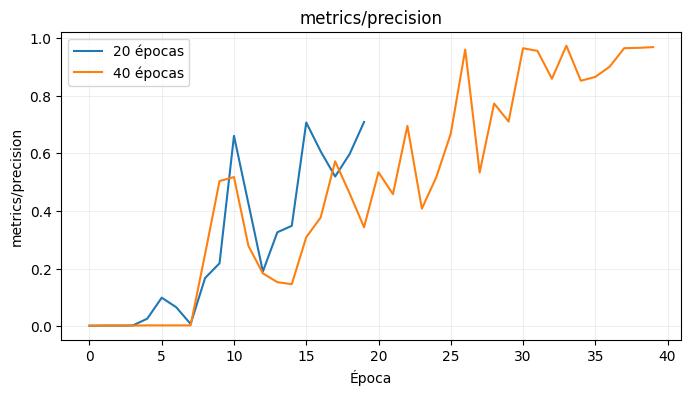

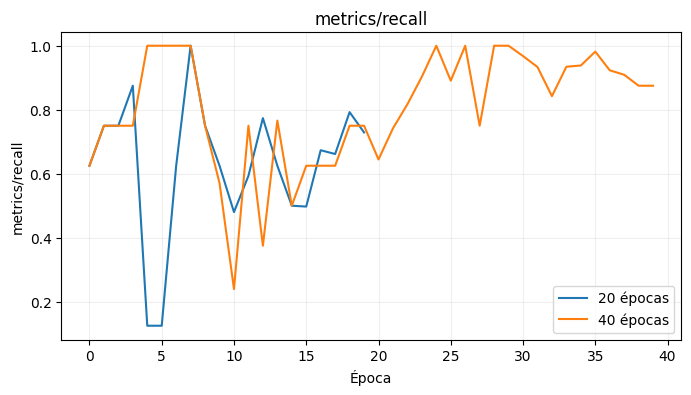

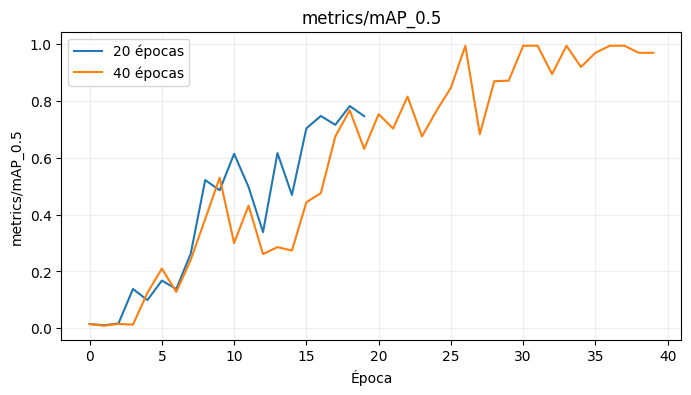

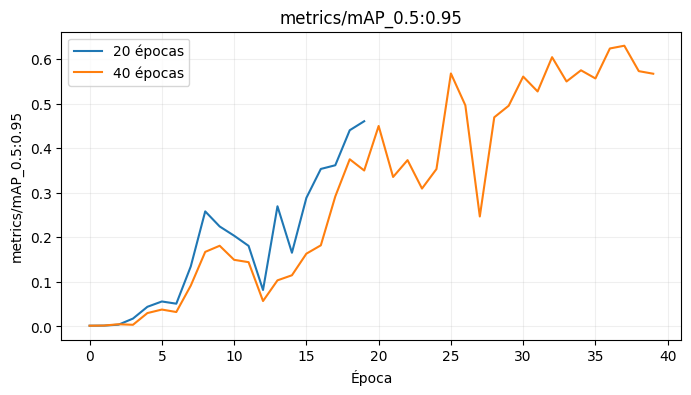

In [12]:
import matplotlib.pyplot as plt

def find_col(df, key):
    for c in df.columns:
        if key.lower() in c.lower():
            return c
    return None

metric_keys = ['metrics/precision', 'metrics/recall', 'metrics/mAP_0.5', 'metrics/mAP_0.5:0.95']

for key in metric_keys:
    c20 = find_col(df20, key)
    c40 = find_col(df40, key)
    if c20 and c40:
        plt.figure(figsize=(8,4))
        plt.plot(df20[c20].values, label='20 épocas')
        plt.plot(df40[c40].values, label='40 épocas')
        plt.title(key)
        plt.xlabel('Época')
        plt.ylabel(key)
        plt.legend()
        plt.grid(True, alpha=.2)
        plt.show()

In [13]:
def summarize_run(df, nome, tempo):
    precision_col = find_col(df, 'metrics/precision')
    recall_col = find_col(df, 'metrics/recall')
    map50_col = find_col(df, 'metrics/mAP_0.5')
    map5095_col = find_col(df, 'metrics/mAP_0.5:0.95')

    return {
        'modelo': nome,
        'tempo_treino_s': tempo,
        'precision_max': float(df[precision_col].max()) if precision_col else None,
        'recall_max': float(df[recall_col].max()) if recall_col else None,
        'mAP50_max': float(df[map50_col].max()) if map50_col else None,
        'mAP50_95_max': float(df[map5095_col].max()) if map5095_col else None,
    }

resumo_yolo = pd.DataFrame([
    summarize_run(df20, 'YOLO customizada - 20 épocas', tempo_treino_20),
    summarize_run(df40, 'YOLO customizada - 40 épocas', tempo_treino_40),
])

display(resumo_yolo)

,modelo,tempo_treino_s,precision_max,recall_max,mAP50_max,mAP50_95_max
0,YOLO customizada - 20 épocas,1068.223689,0.70886,1.0,0.7825,0.46053
1,YOLO customizada - 40 épocas,1987.353620,0.97348,1.0,0.9950,0.62994


## 11. Matriz de confusão e resultados salvos pelo YOLO

O `val.py` produz arquivos gráficos na pasta de validação. Esta célula exibe os arquivos disponíveis.


 validacao_20_epocas
confusion_matrix.png


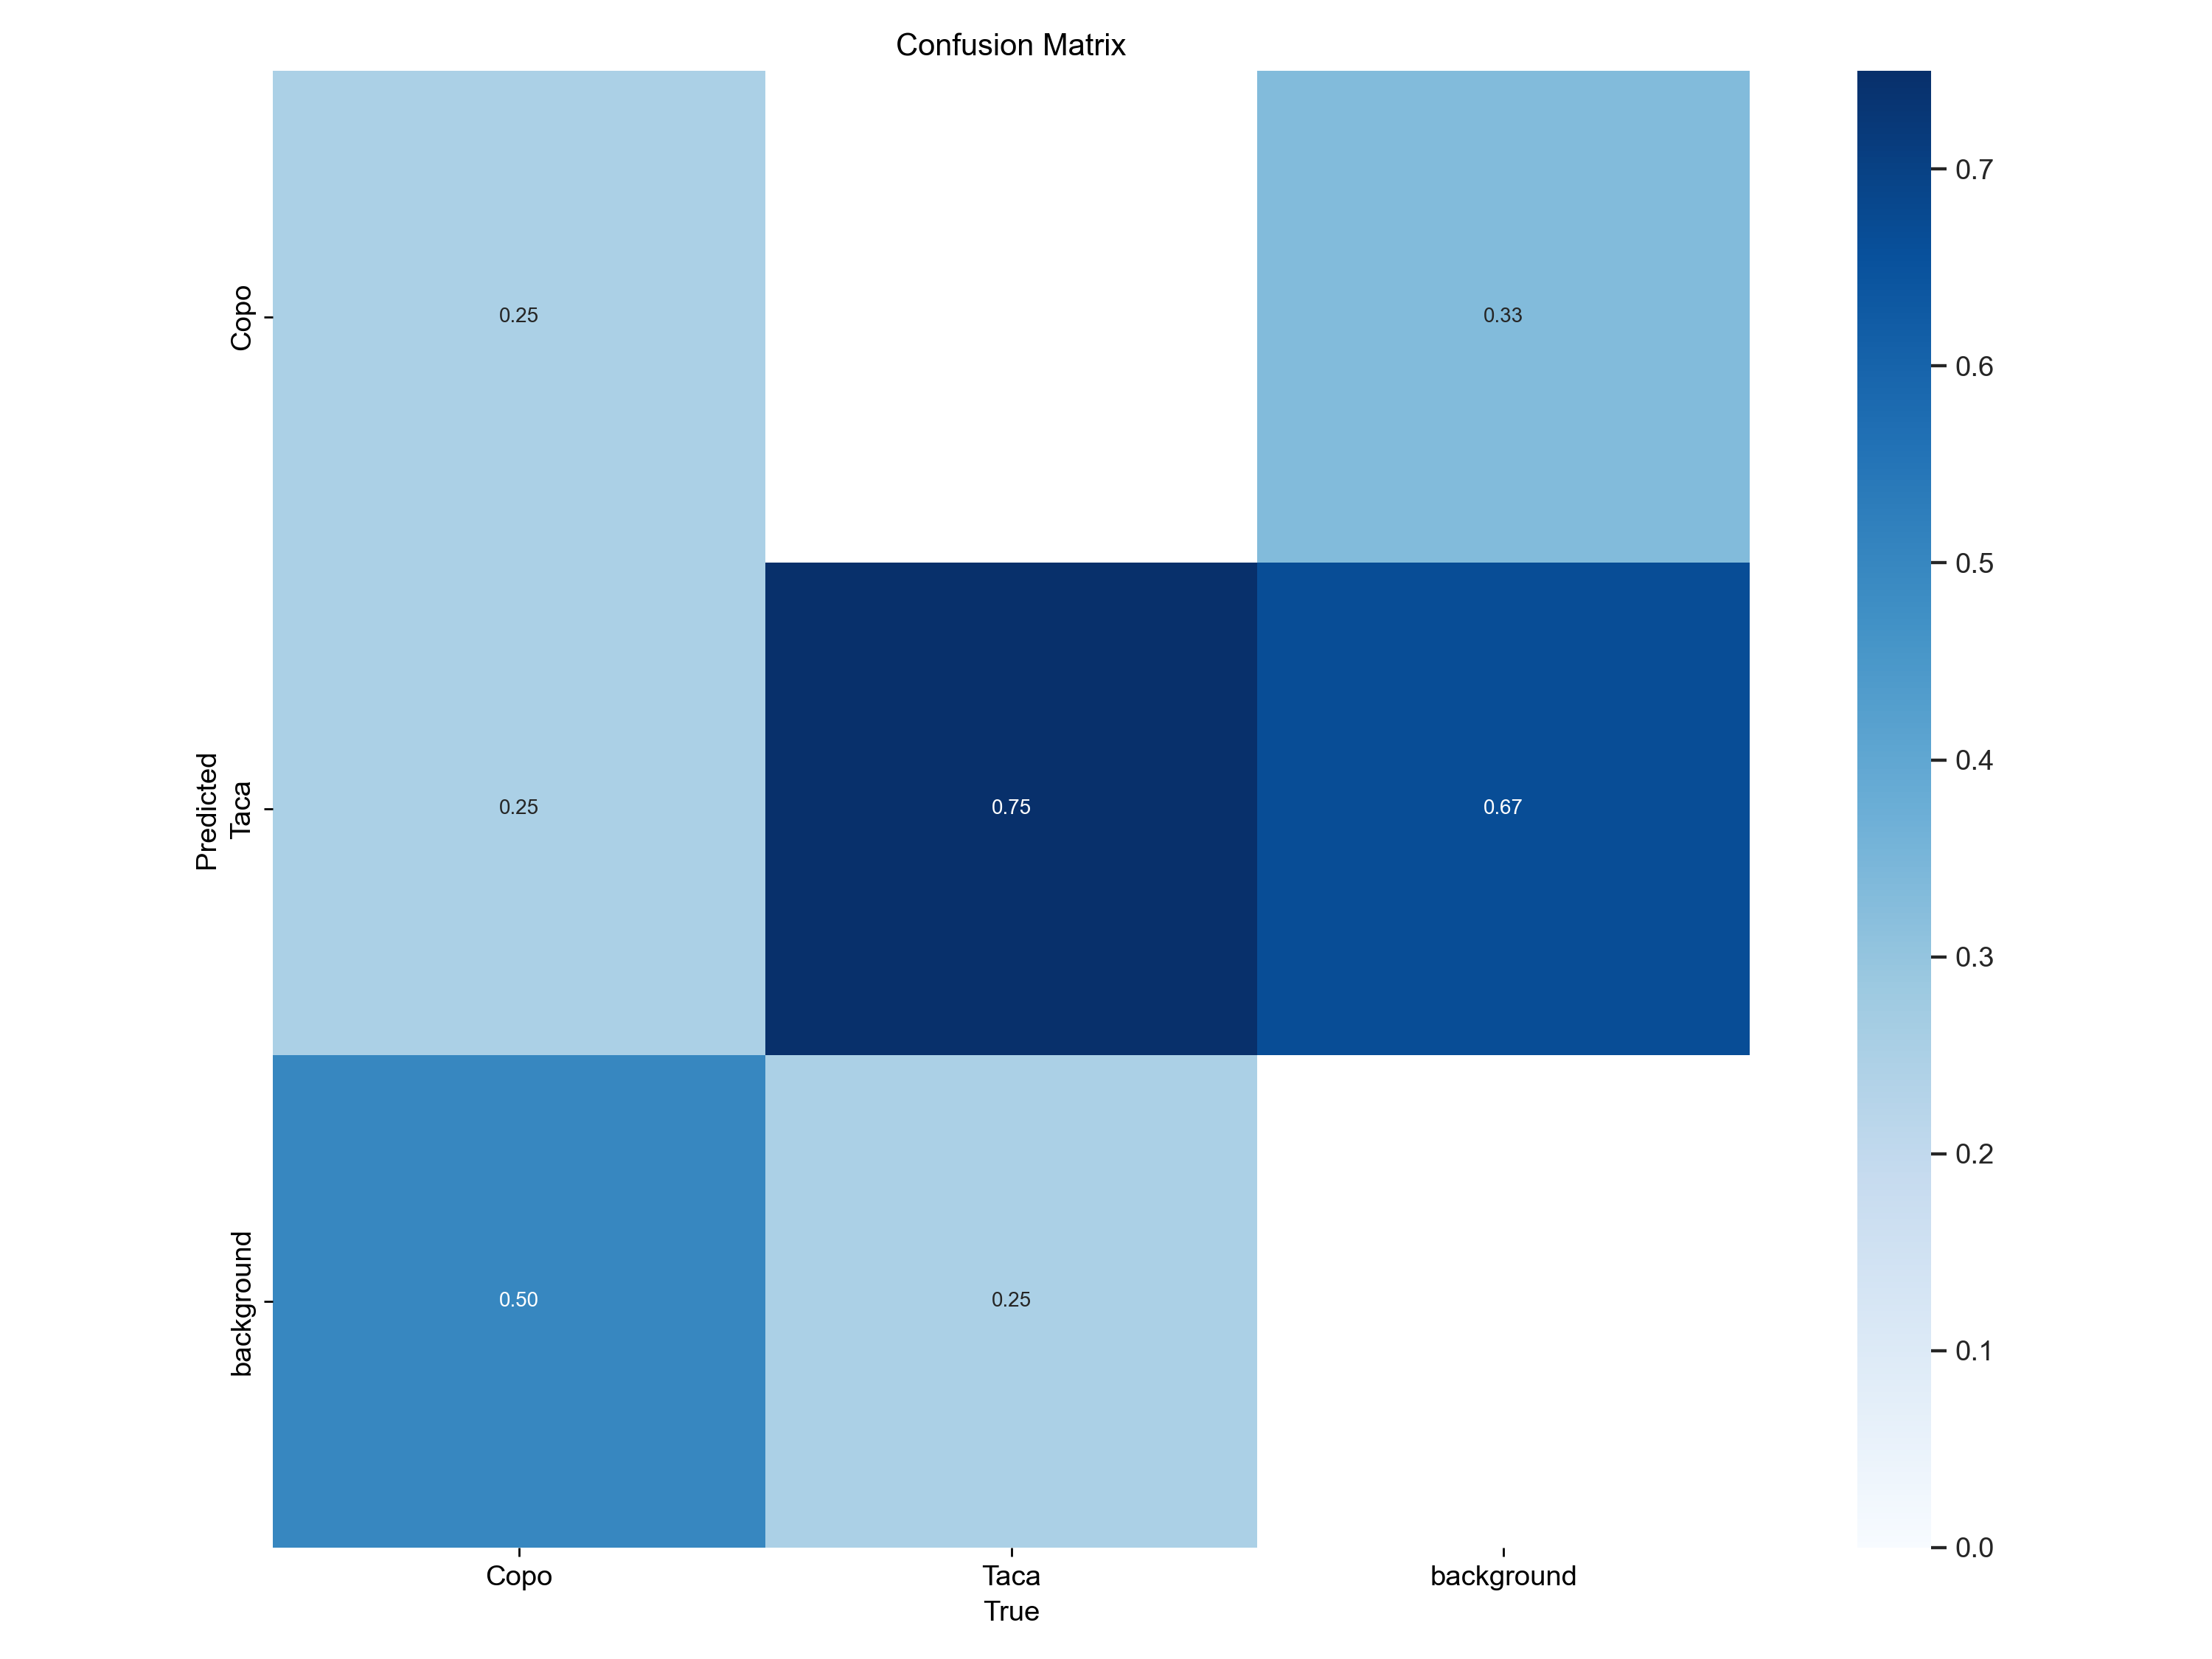

PR_curve.png


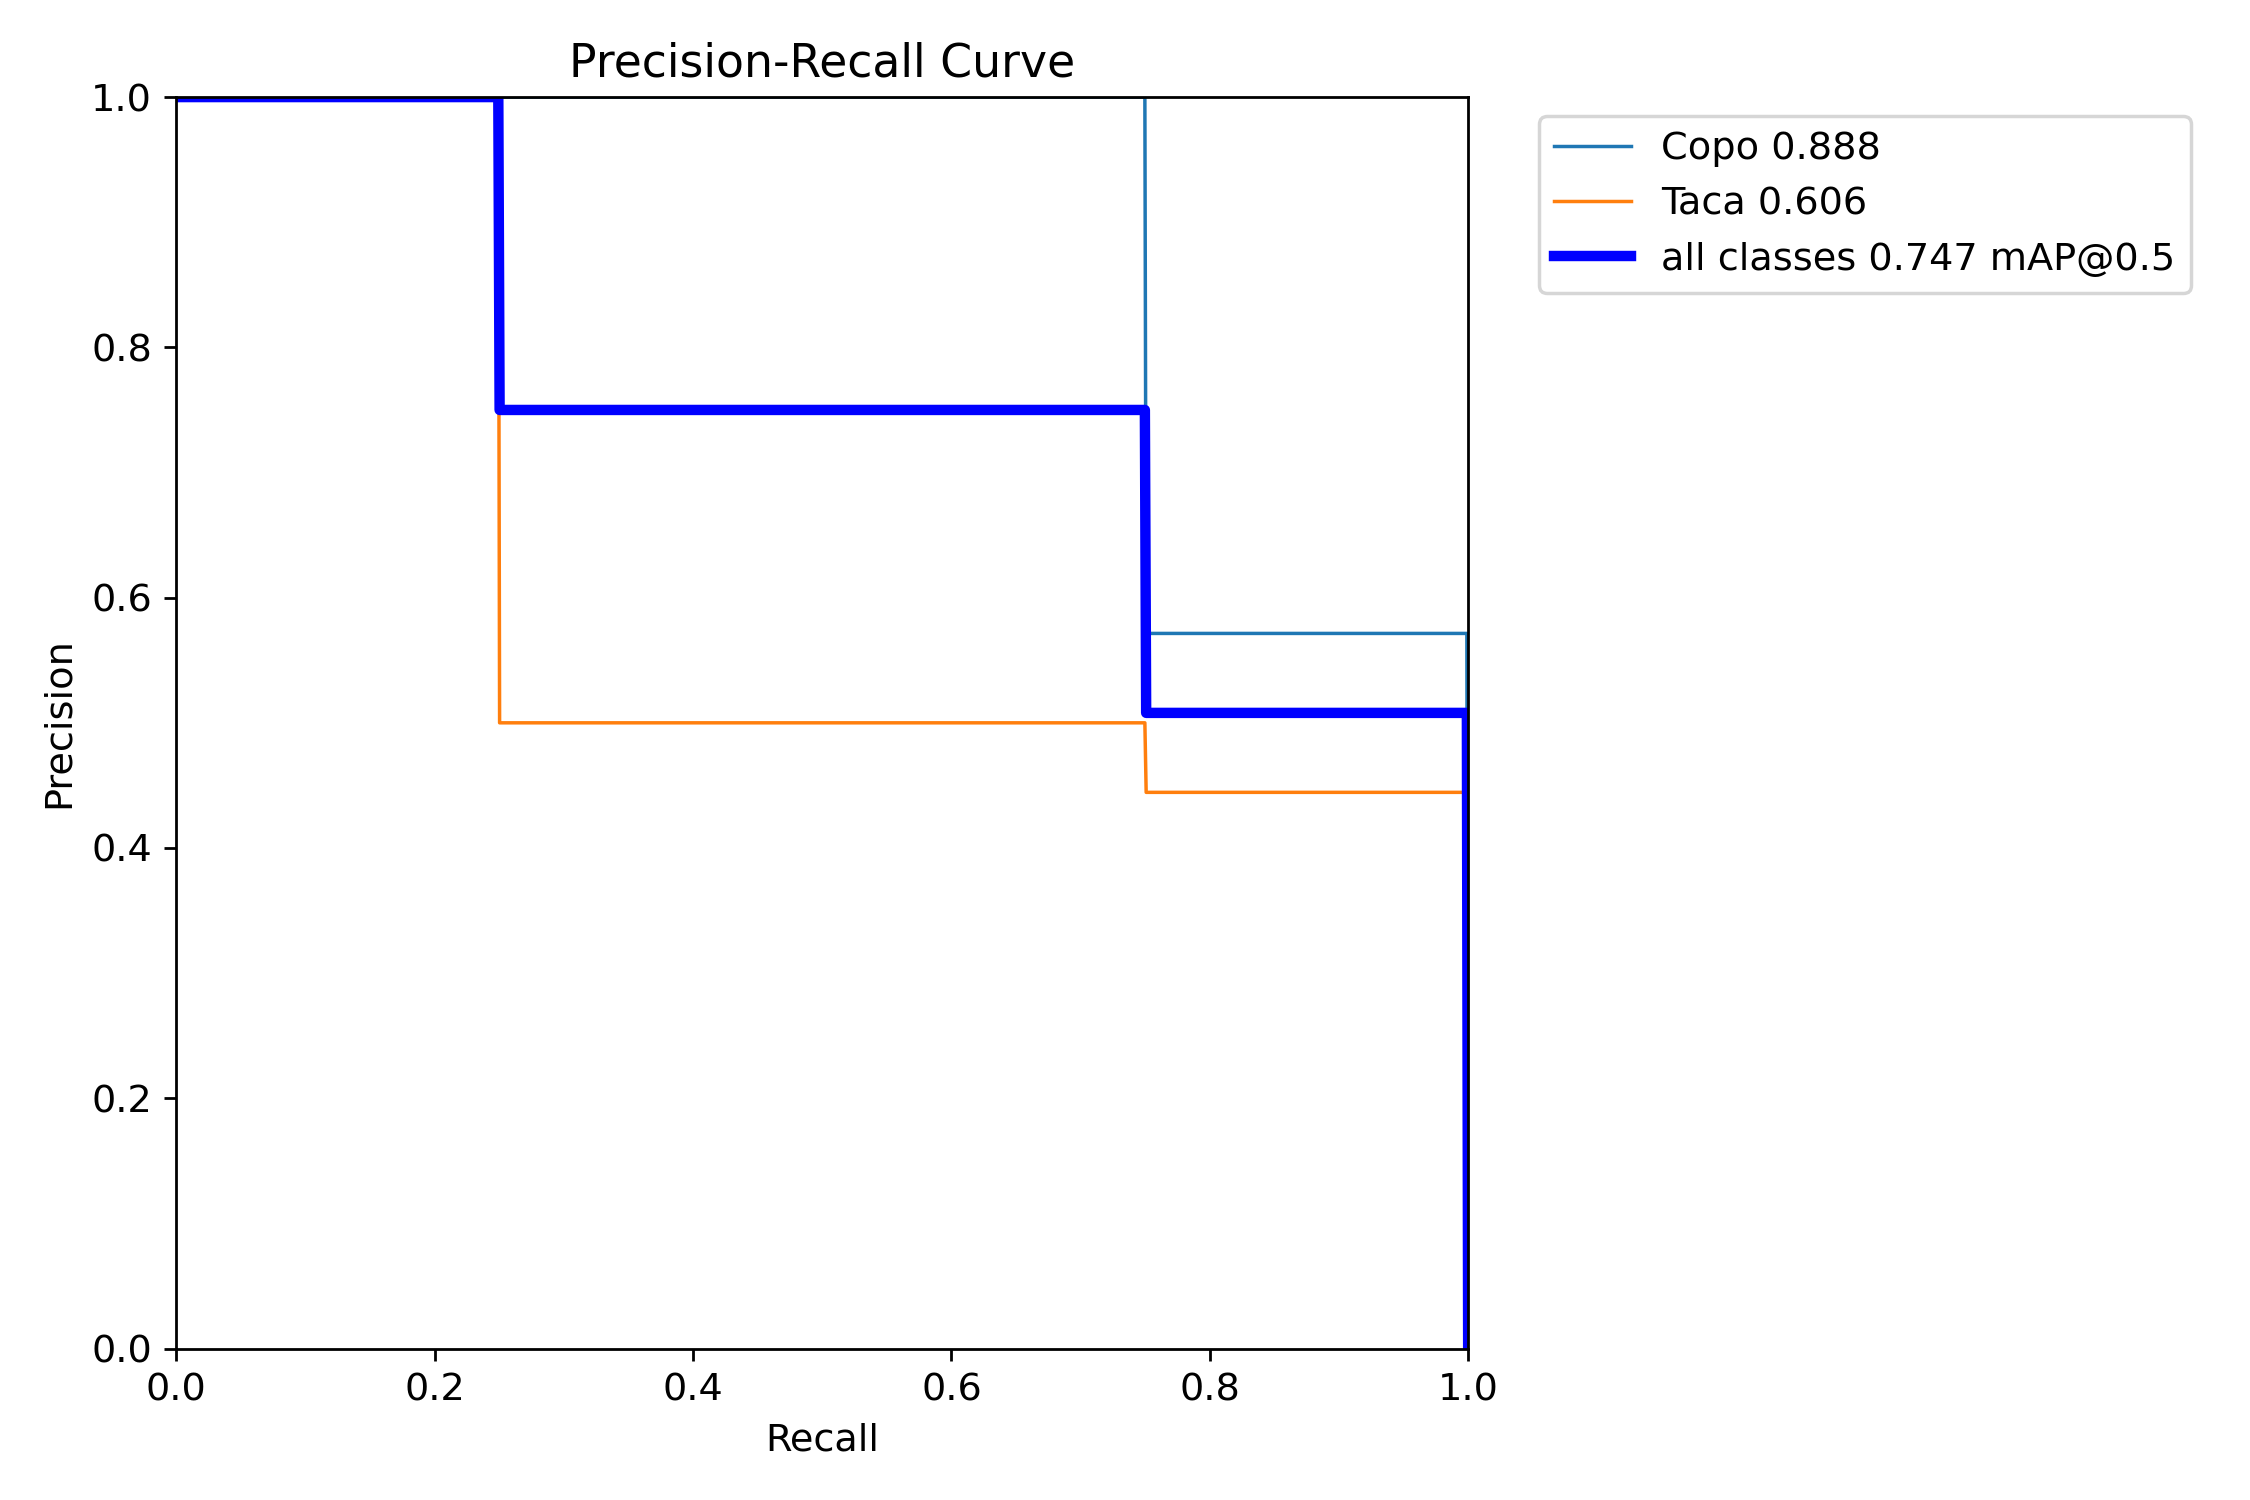

P_curve.png


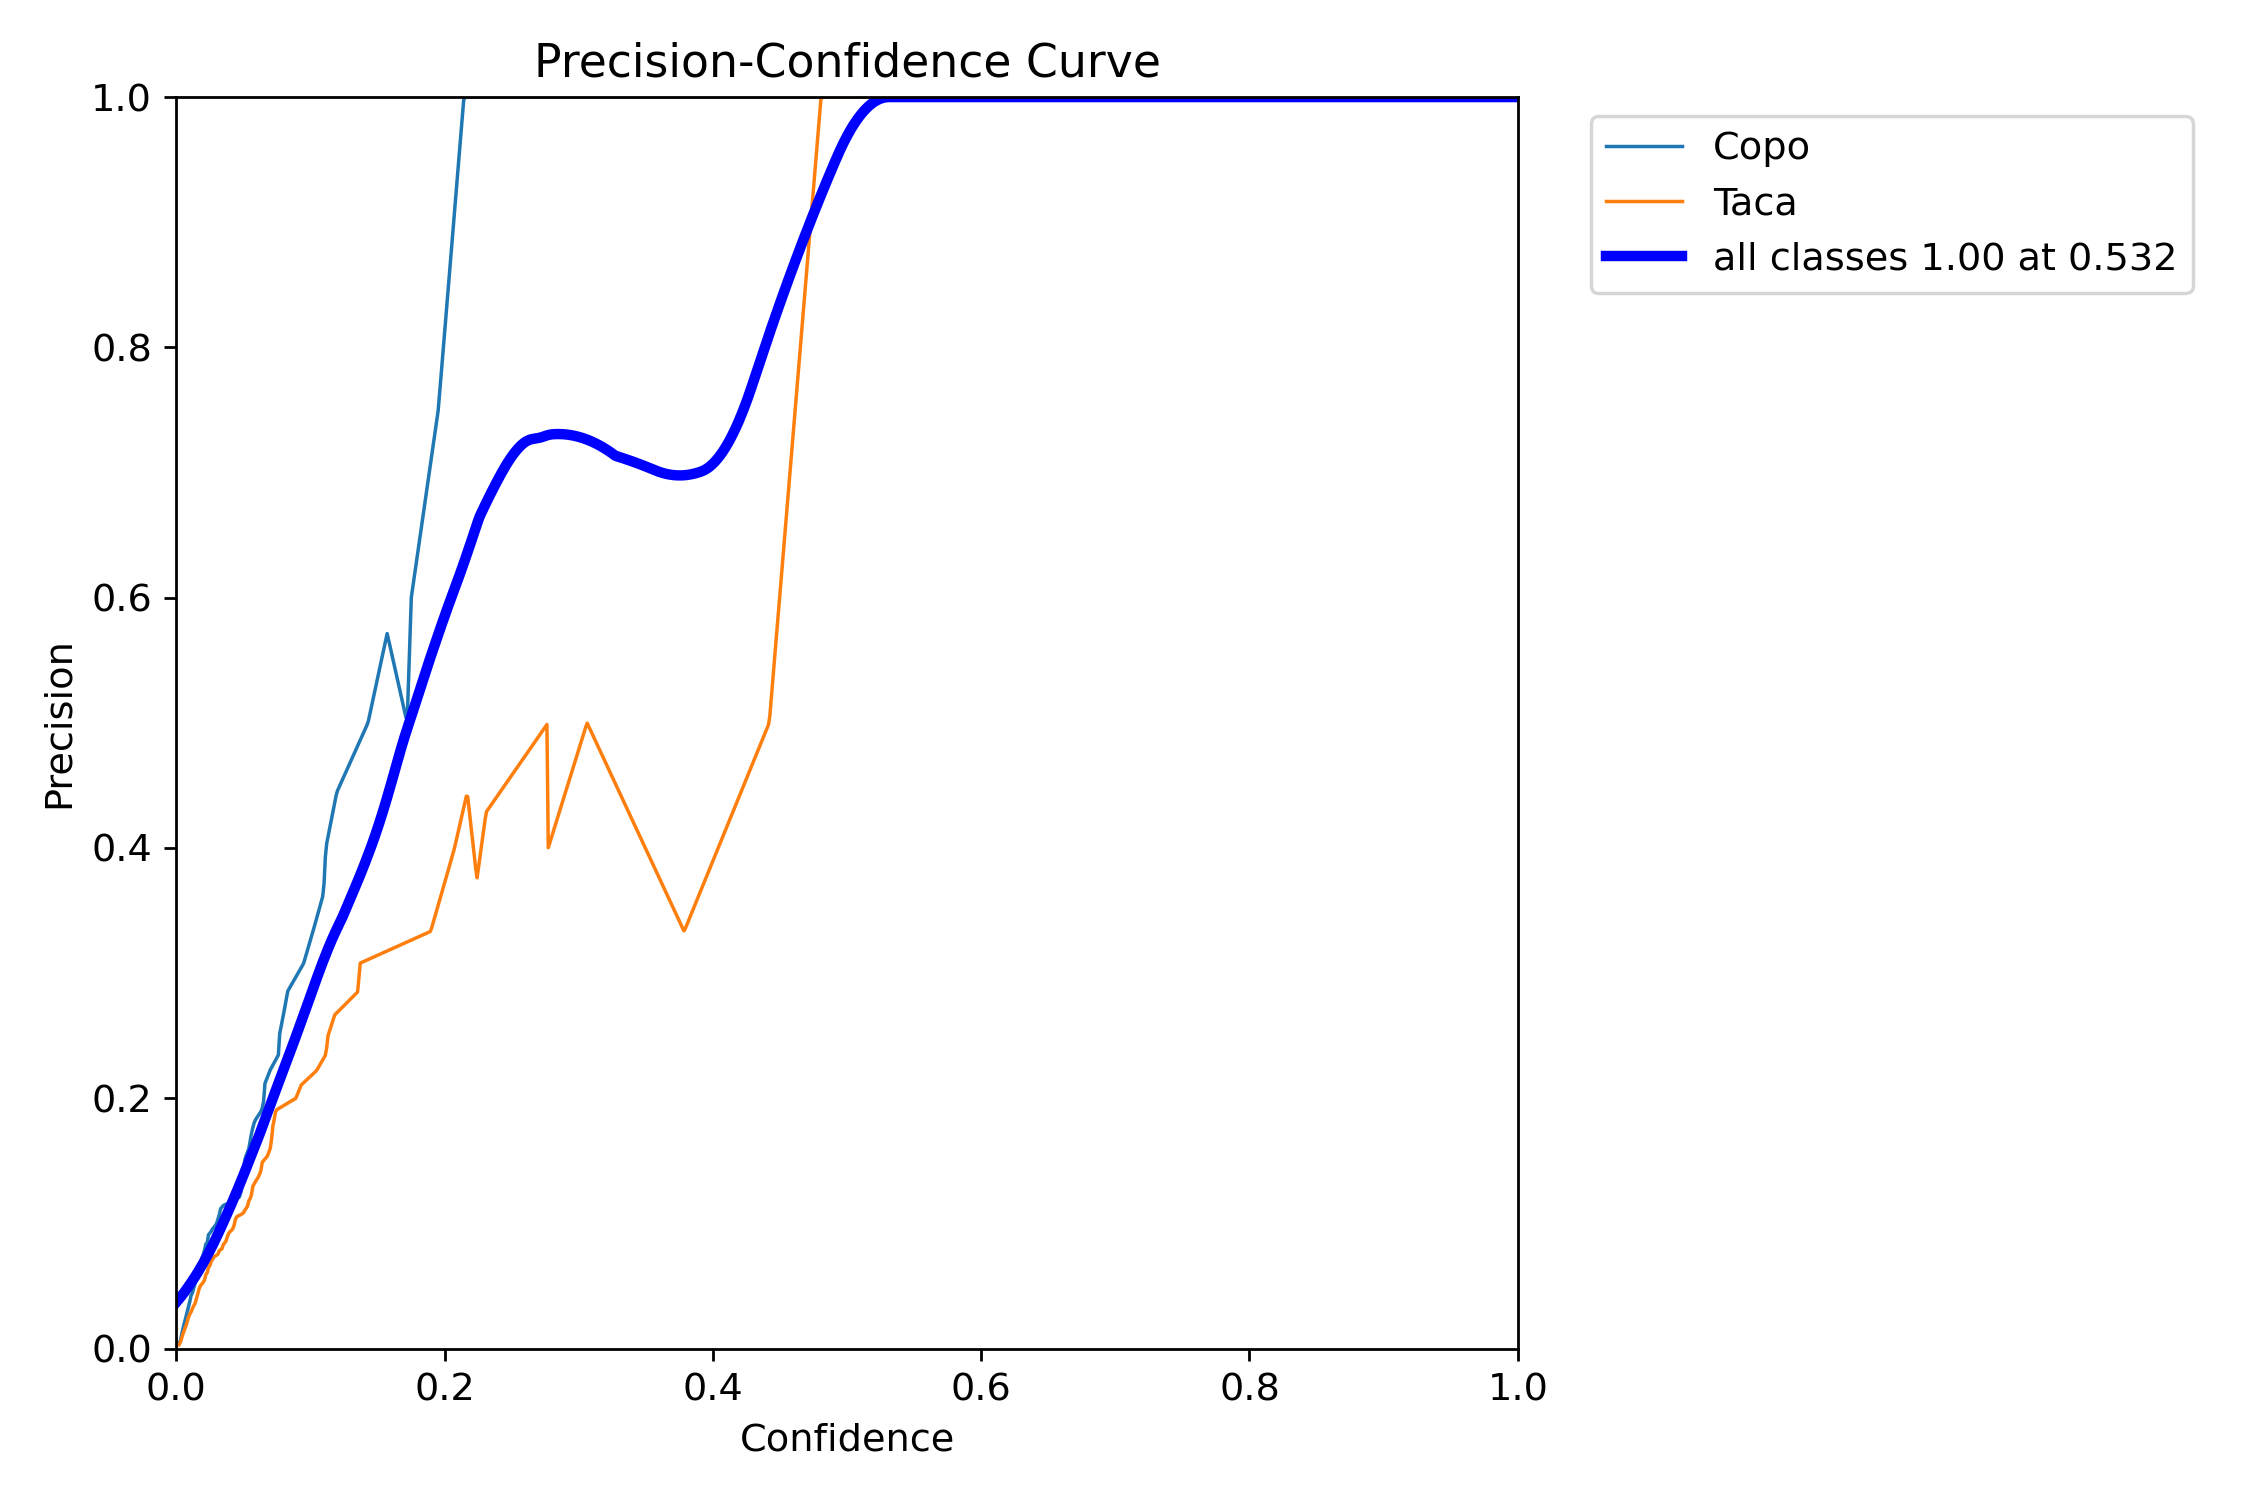

R_curve.png


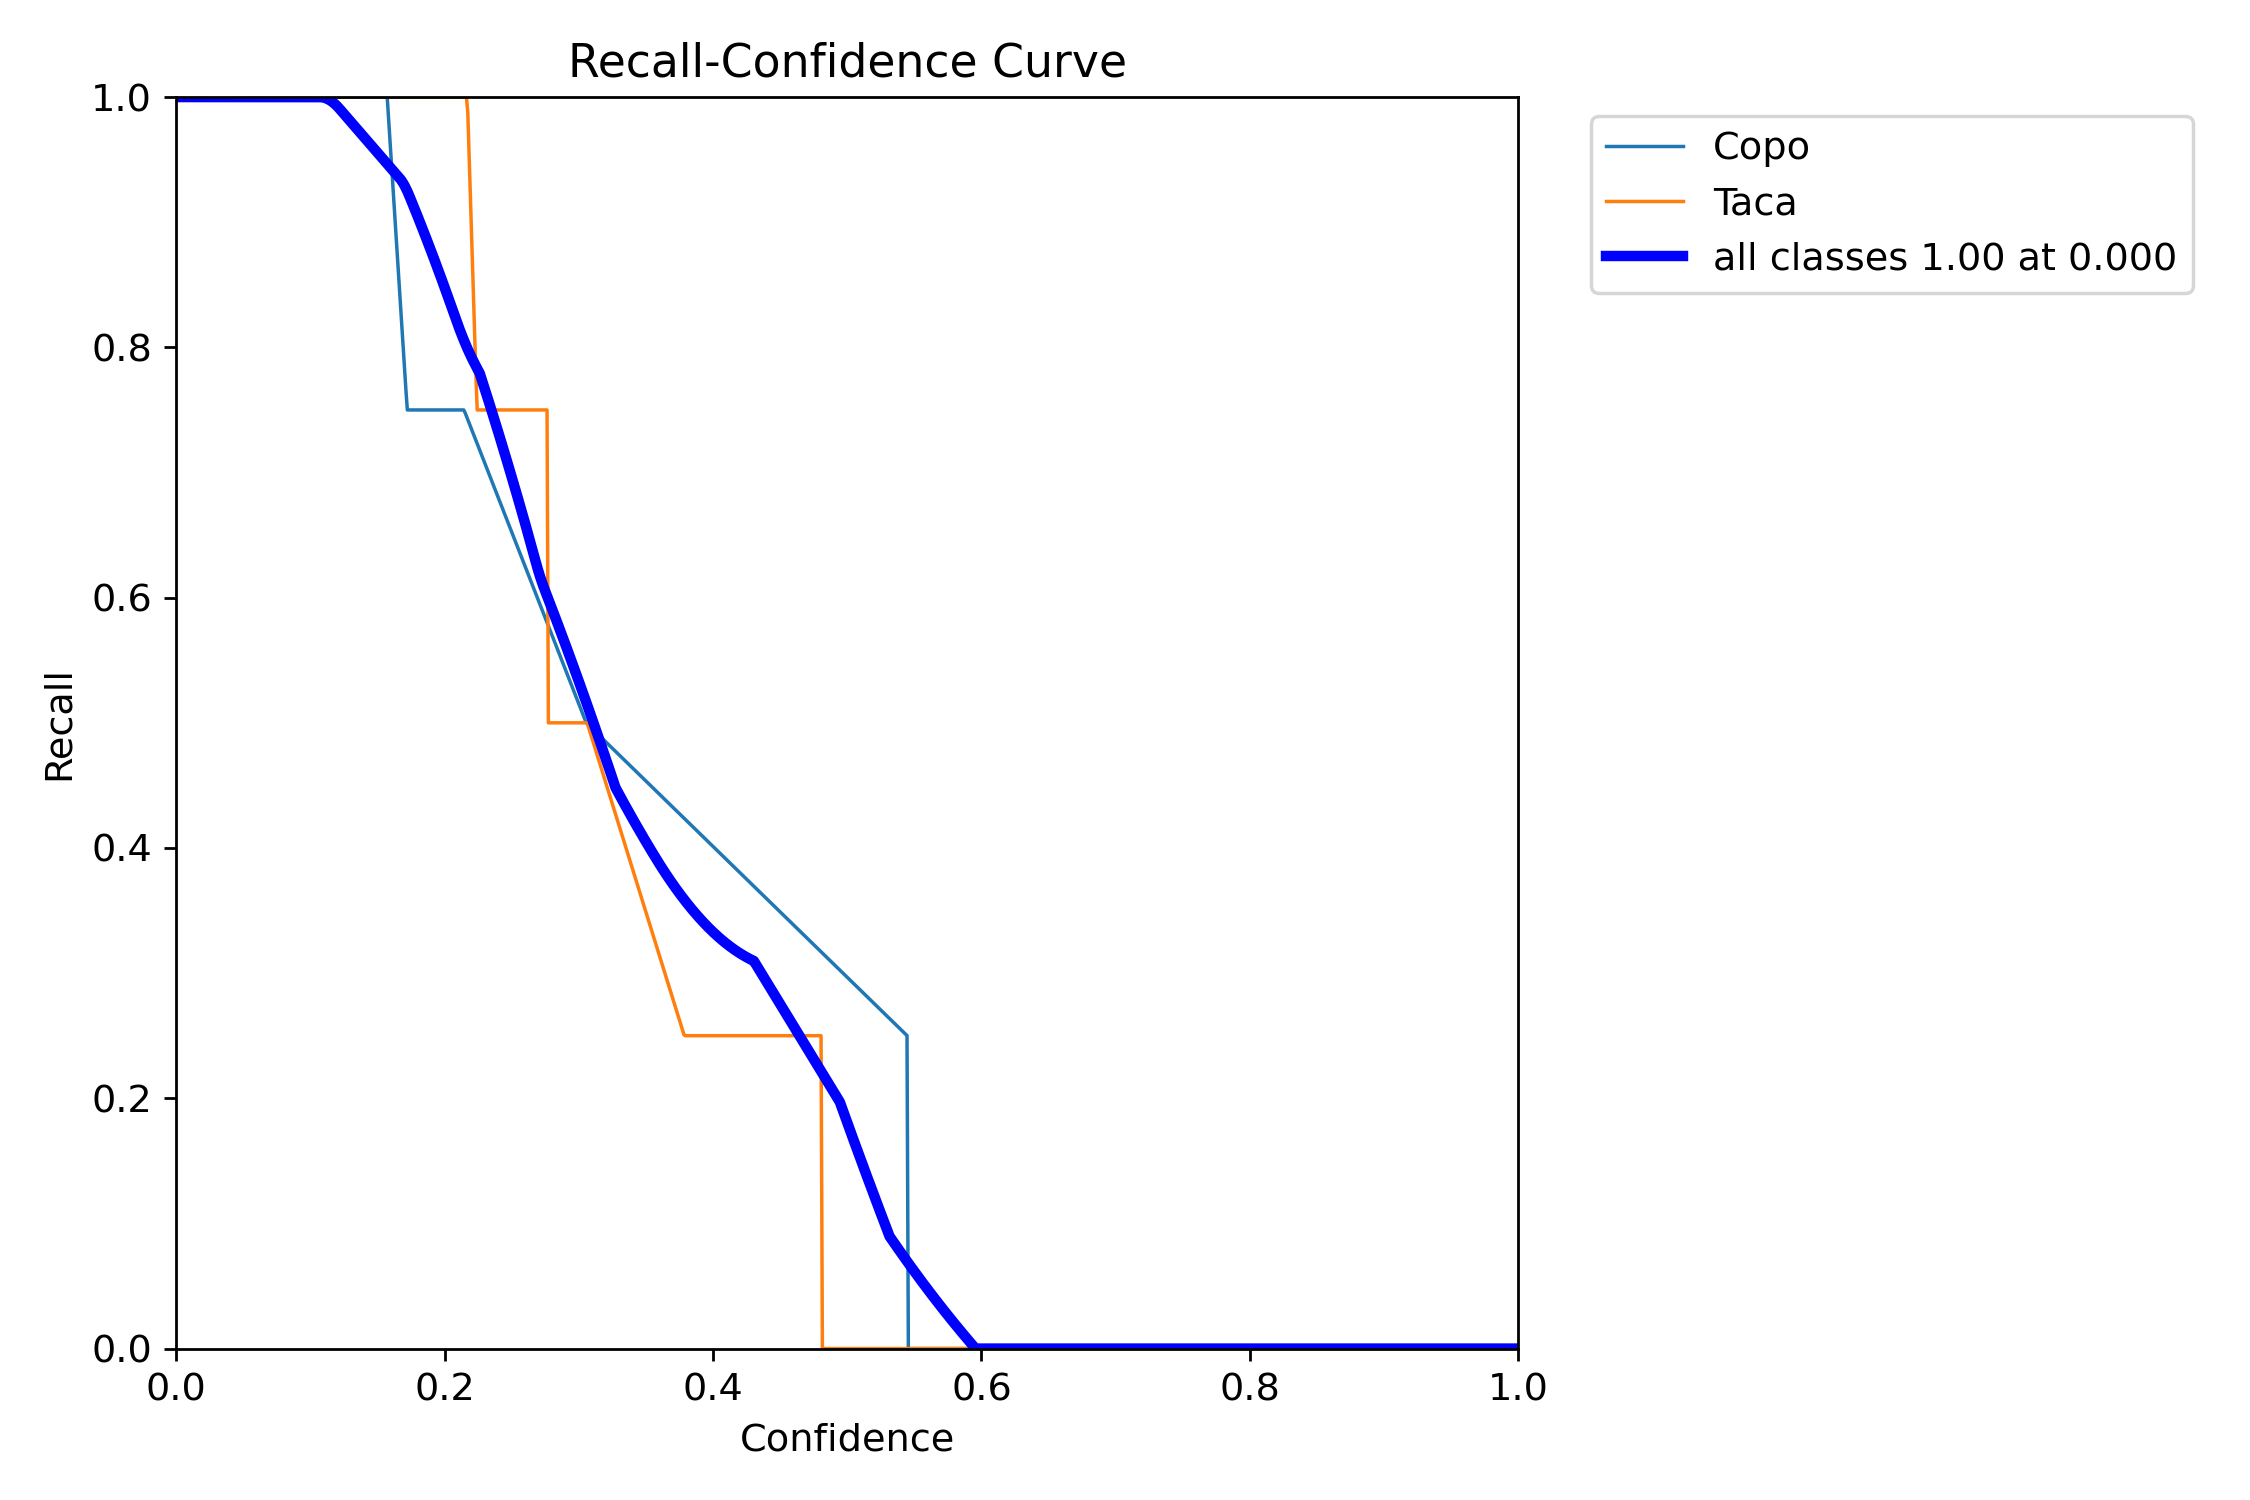

F1_curve.png


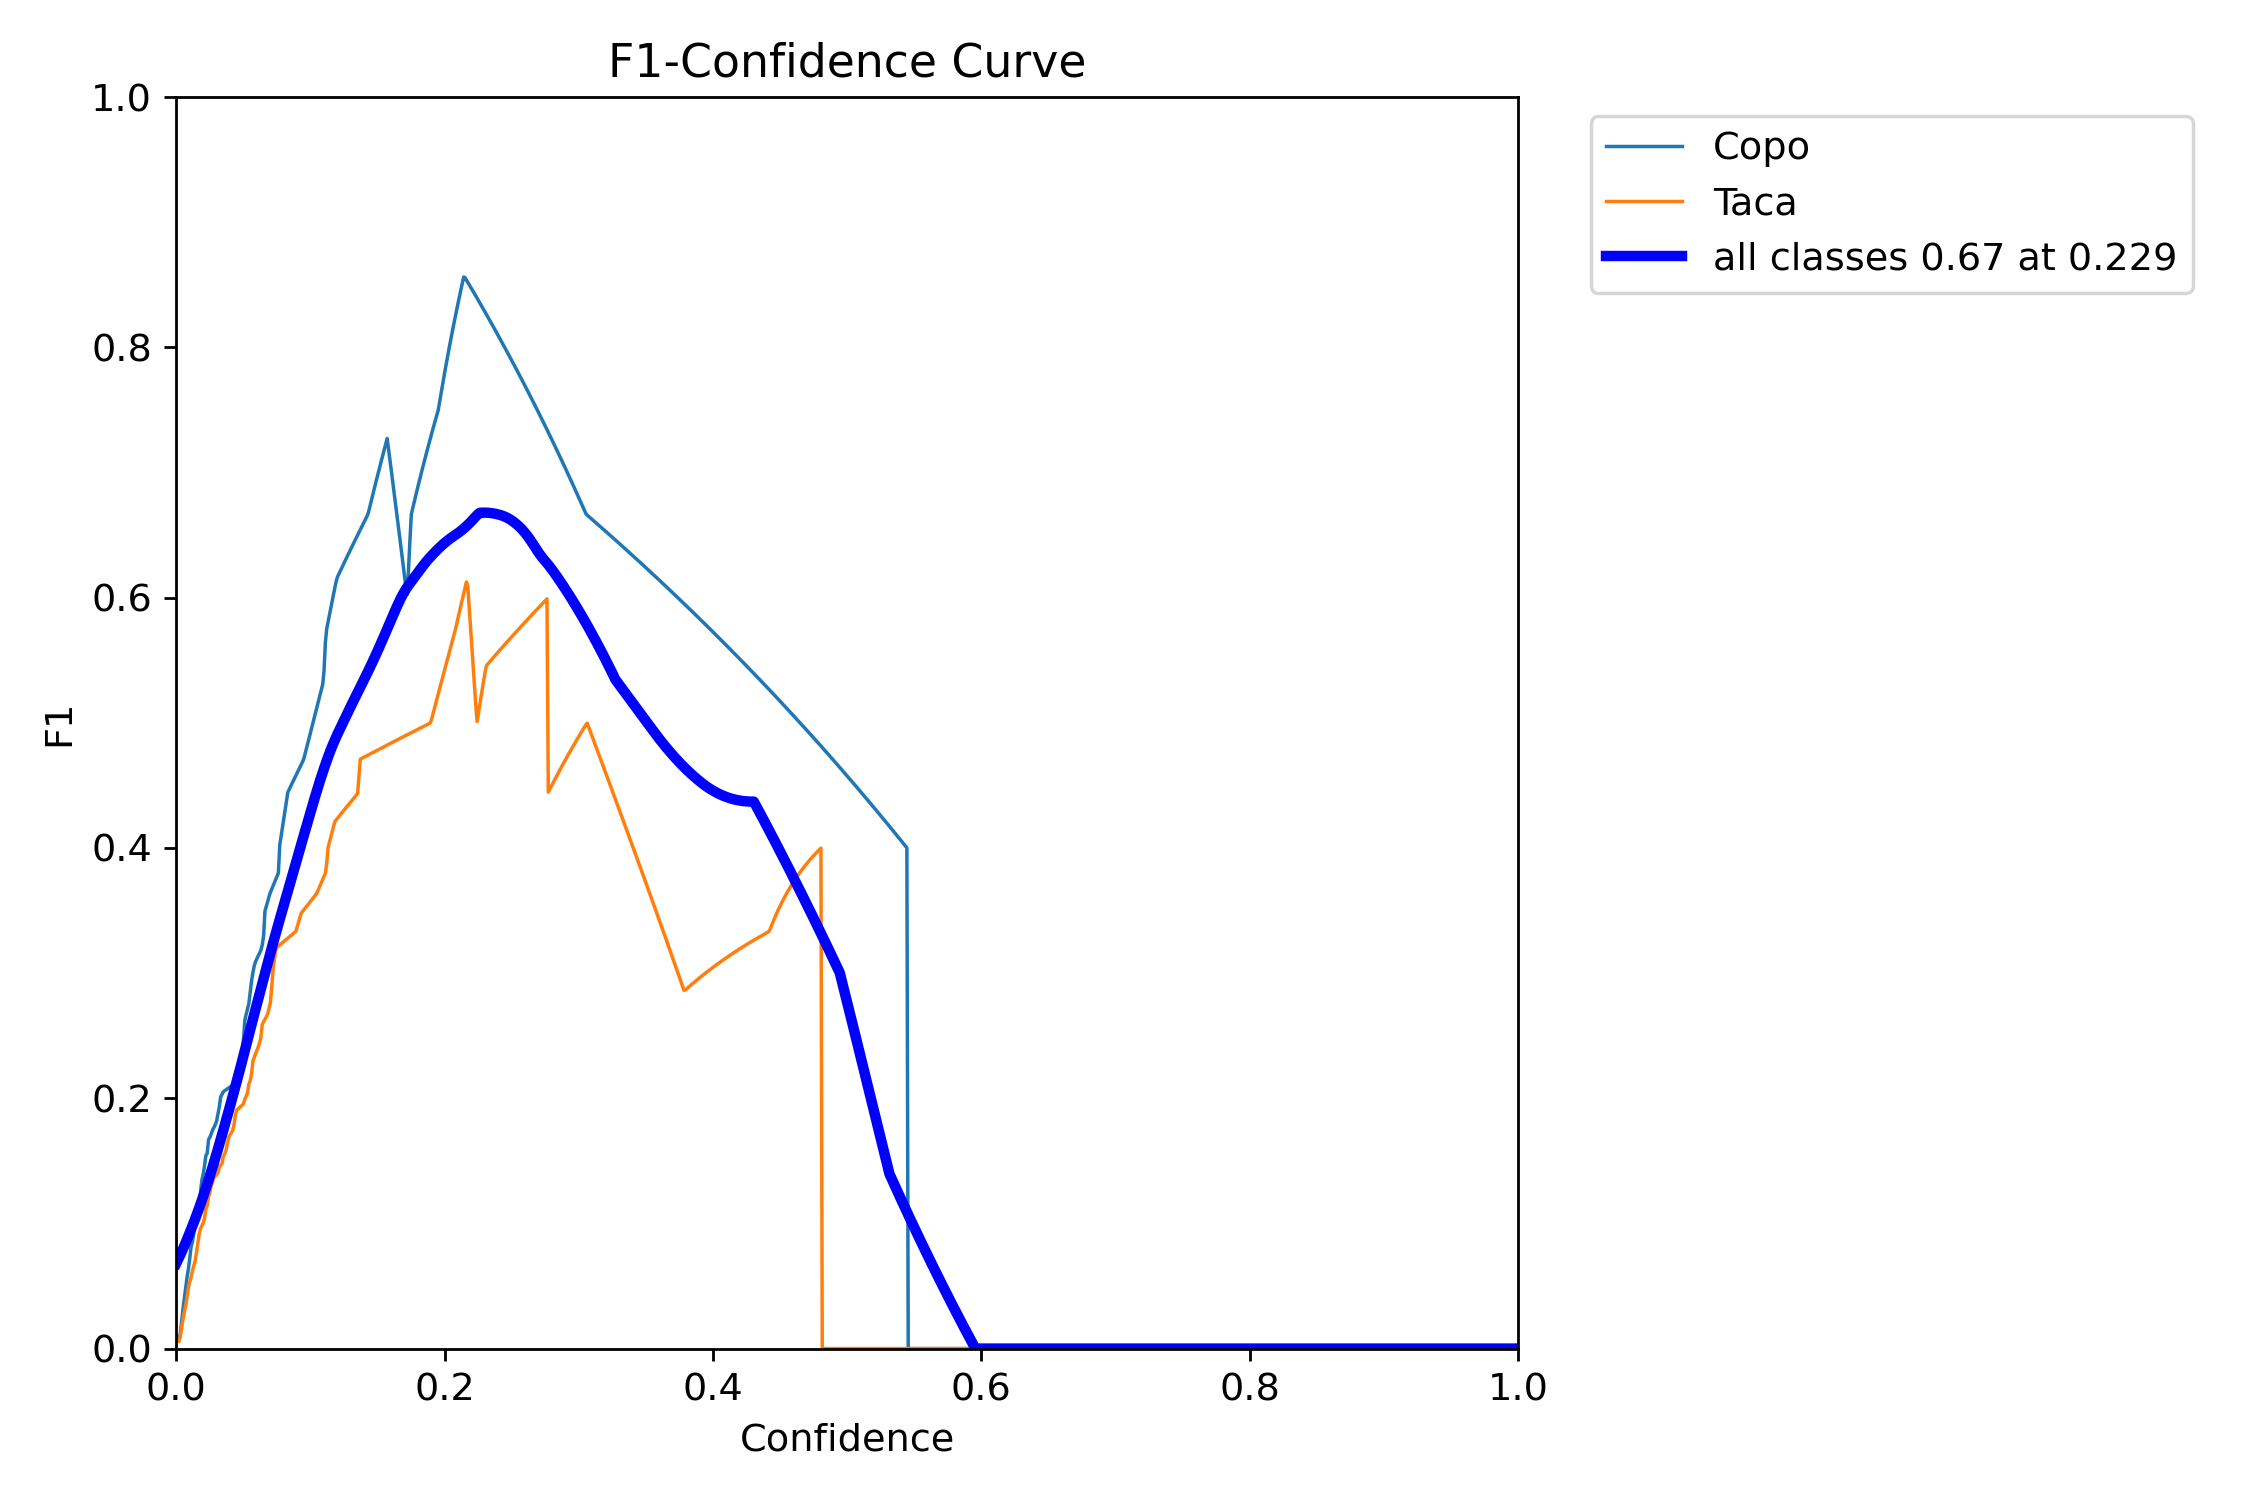


 validacao_40_epocas
confusion_matrix.png


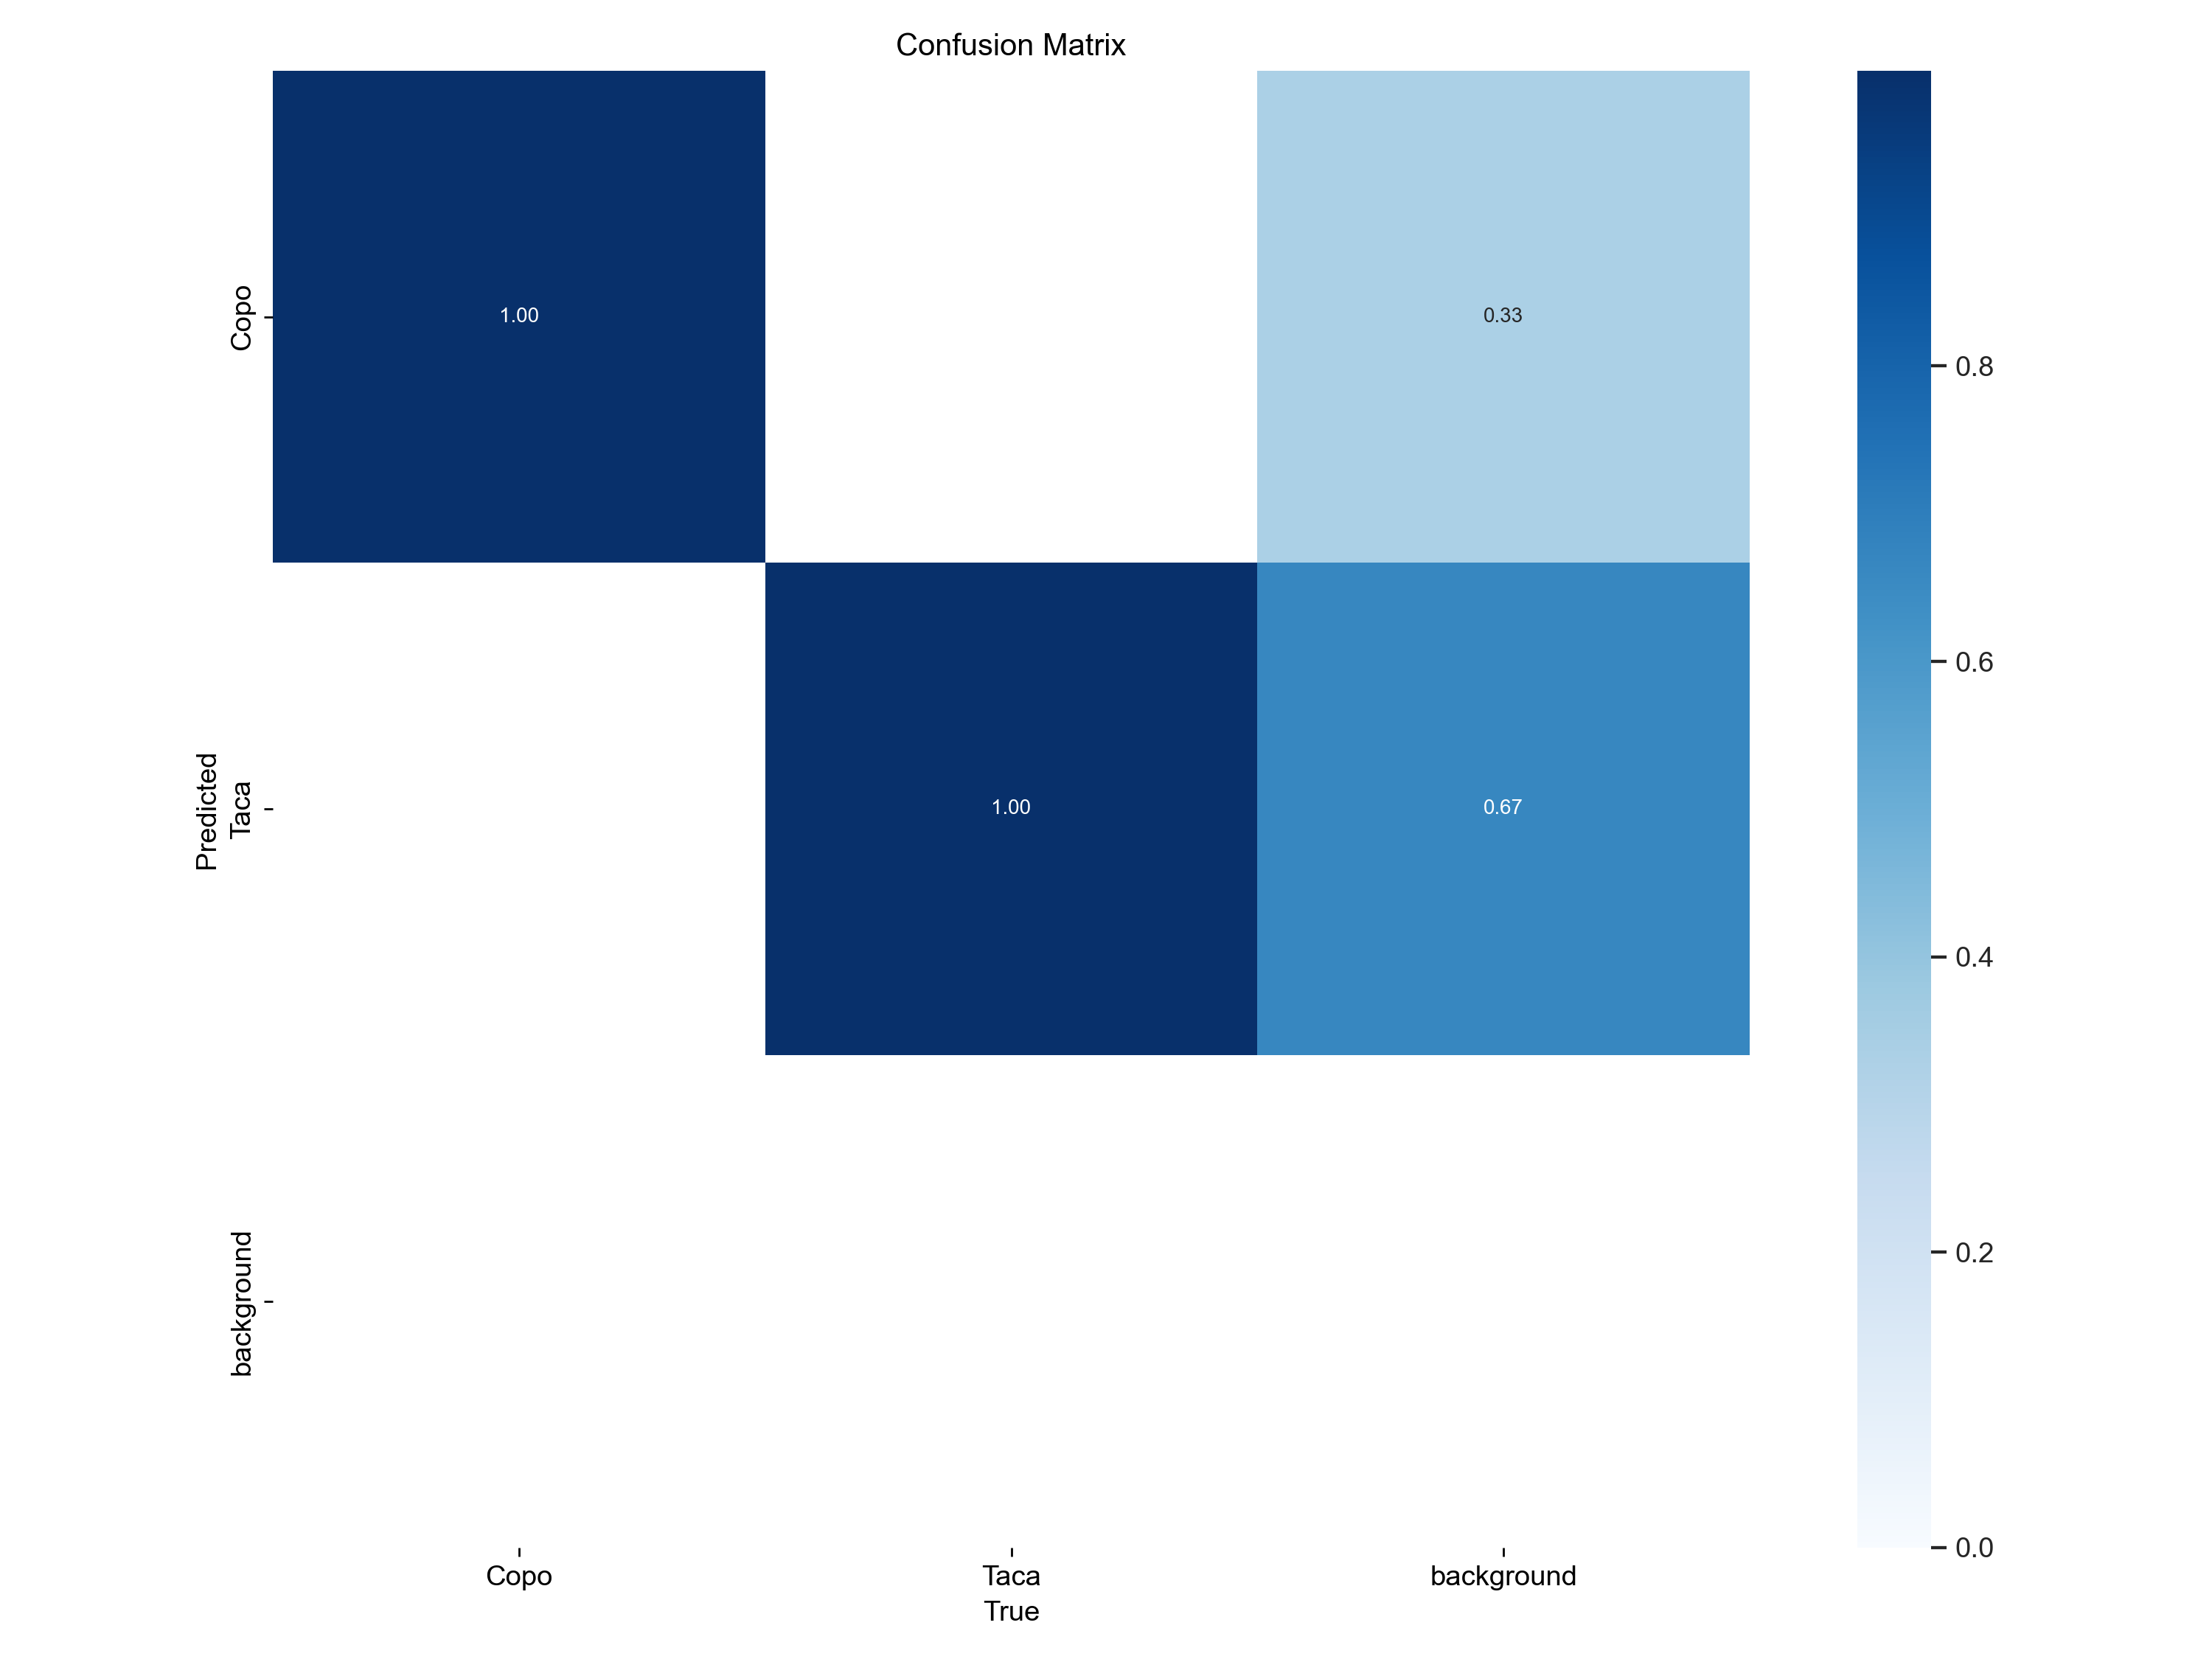

PR_curve.png


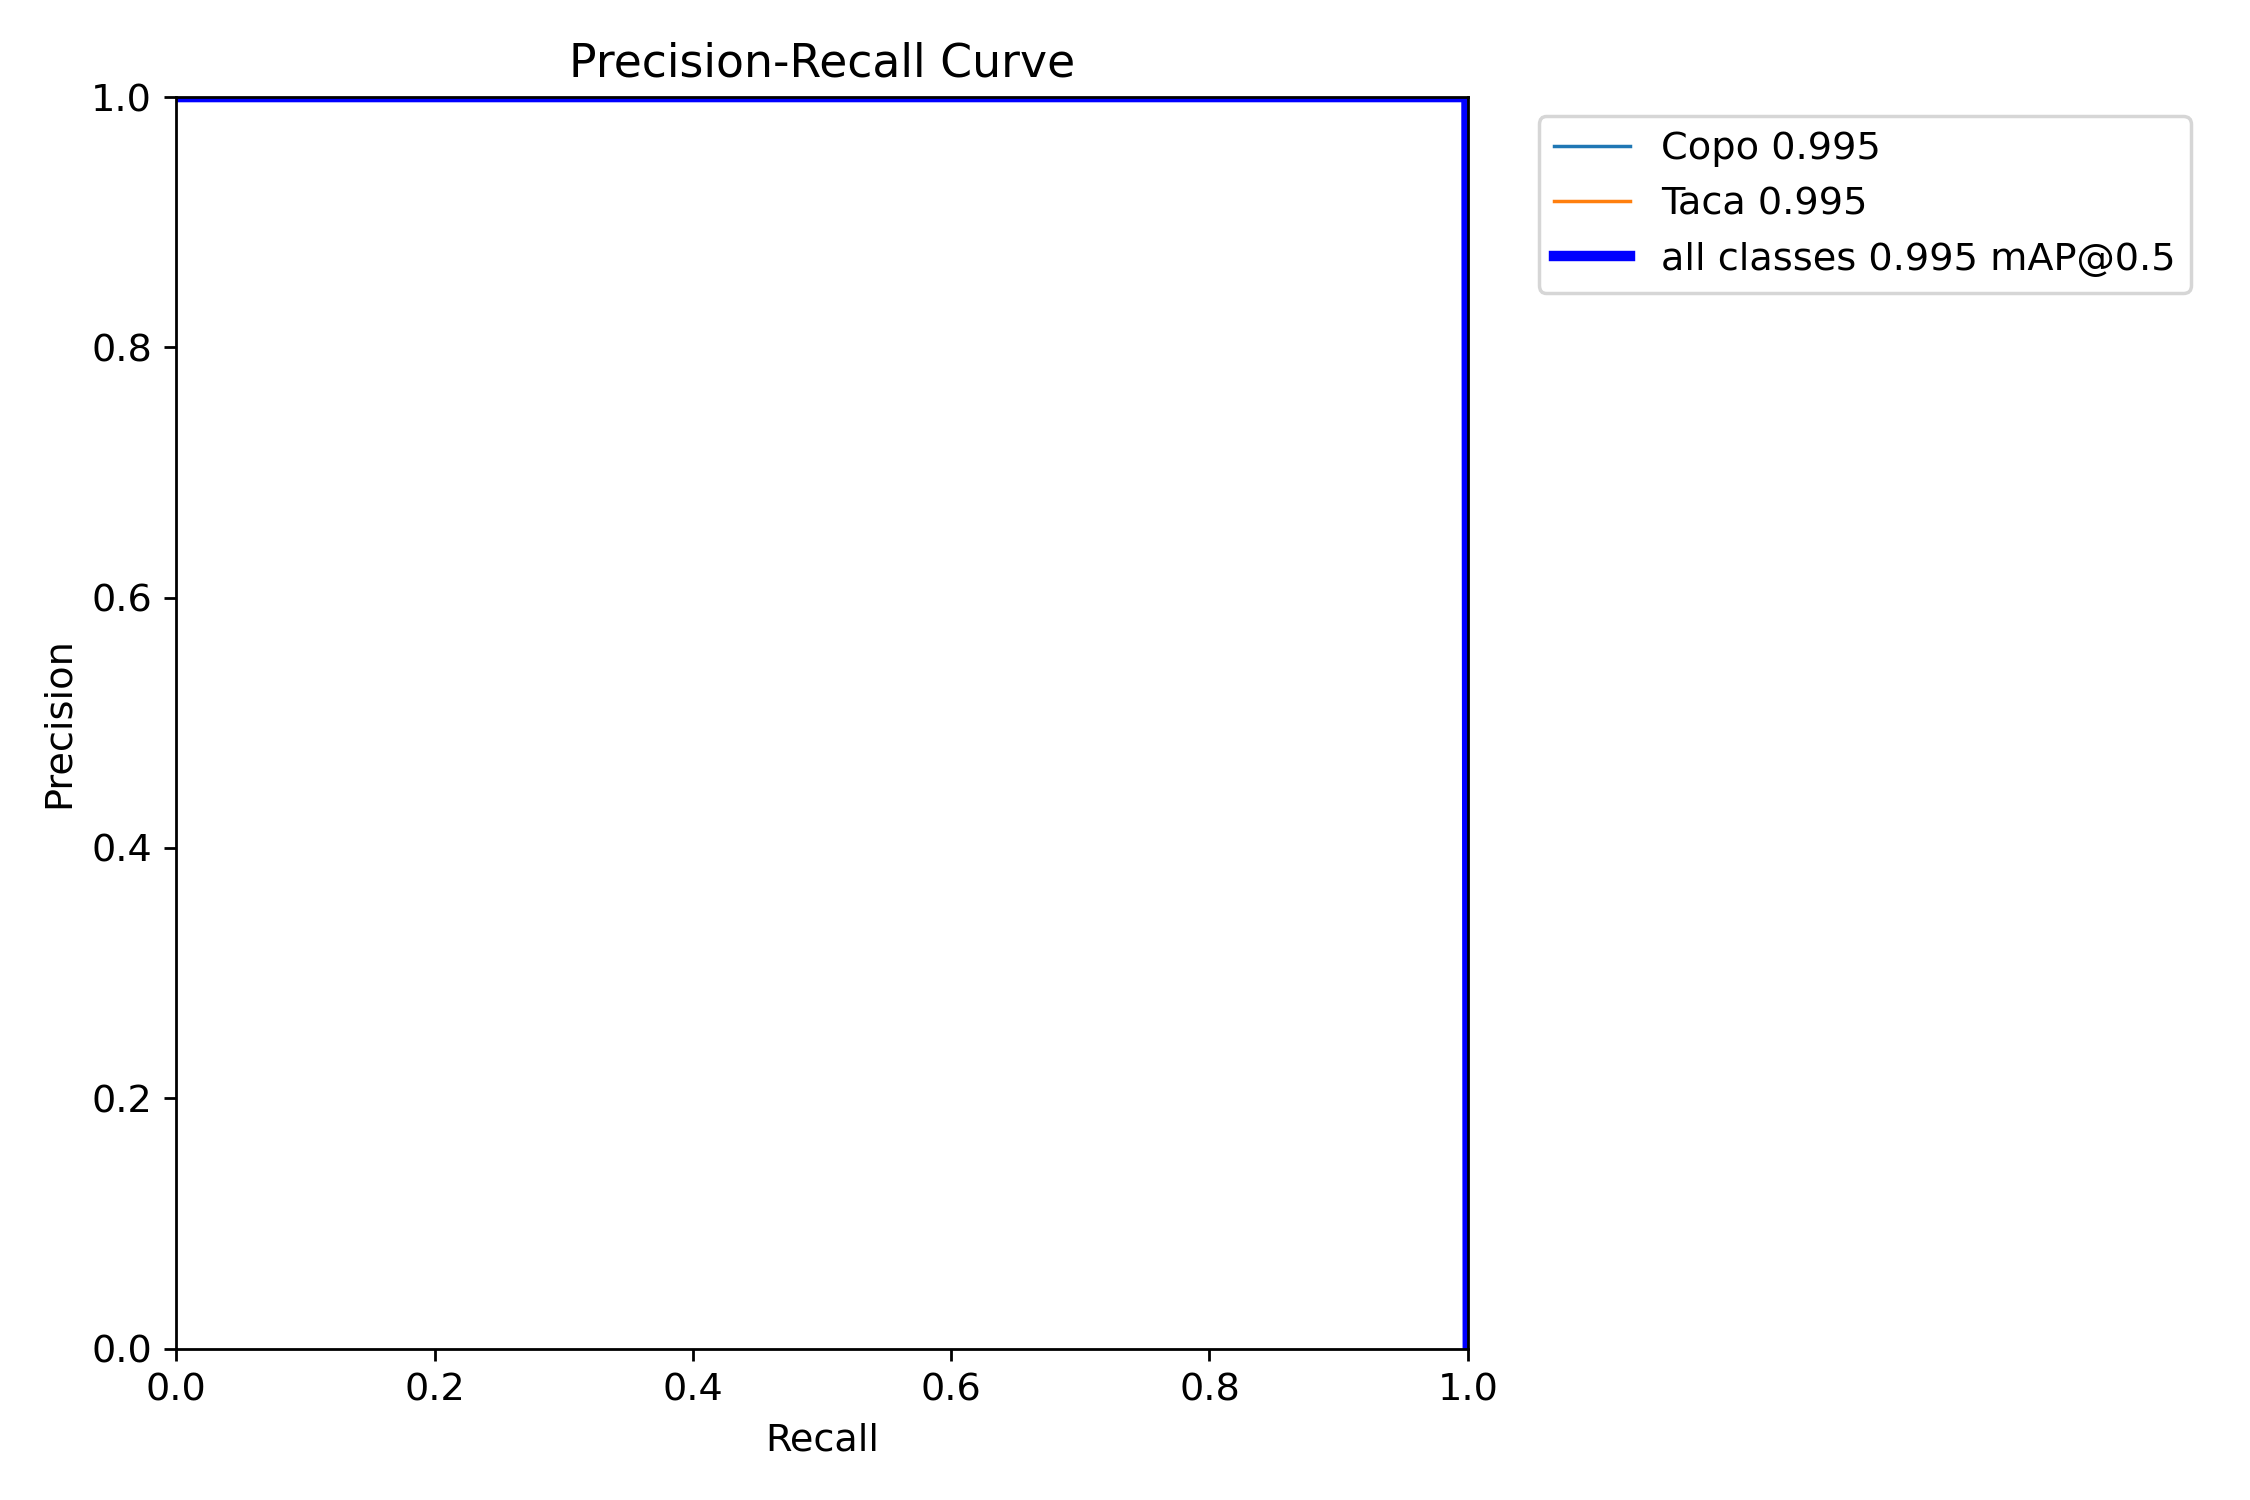

P_curve.png


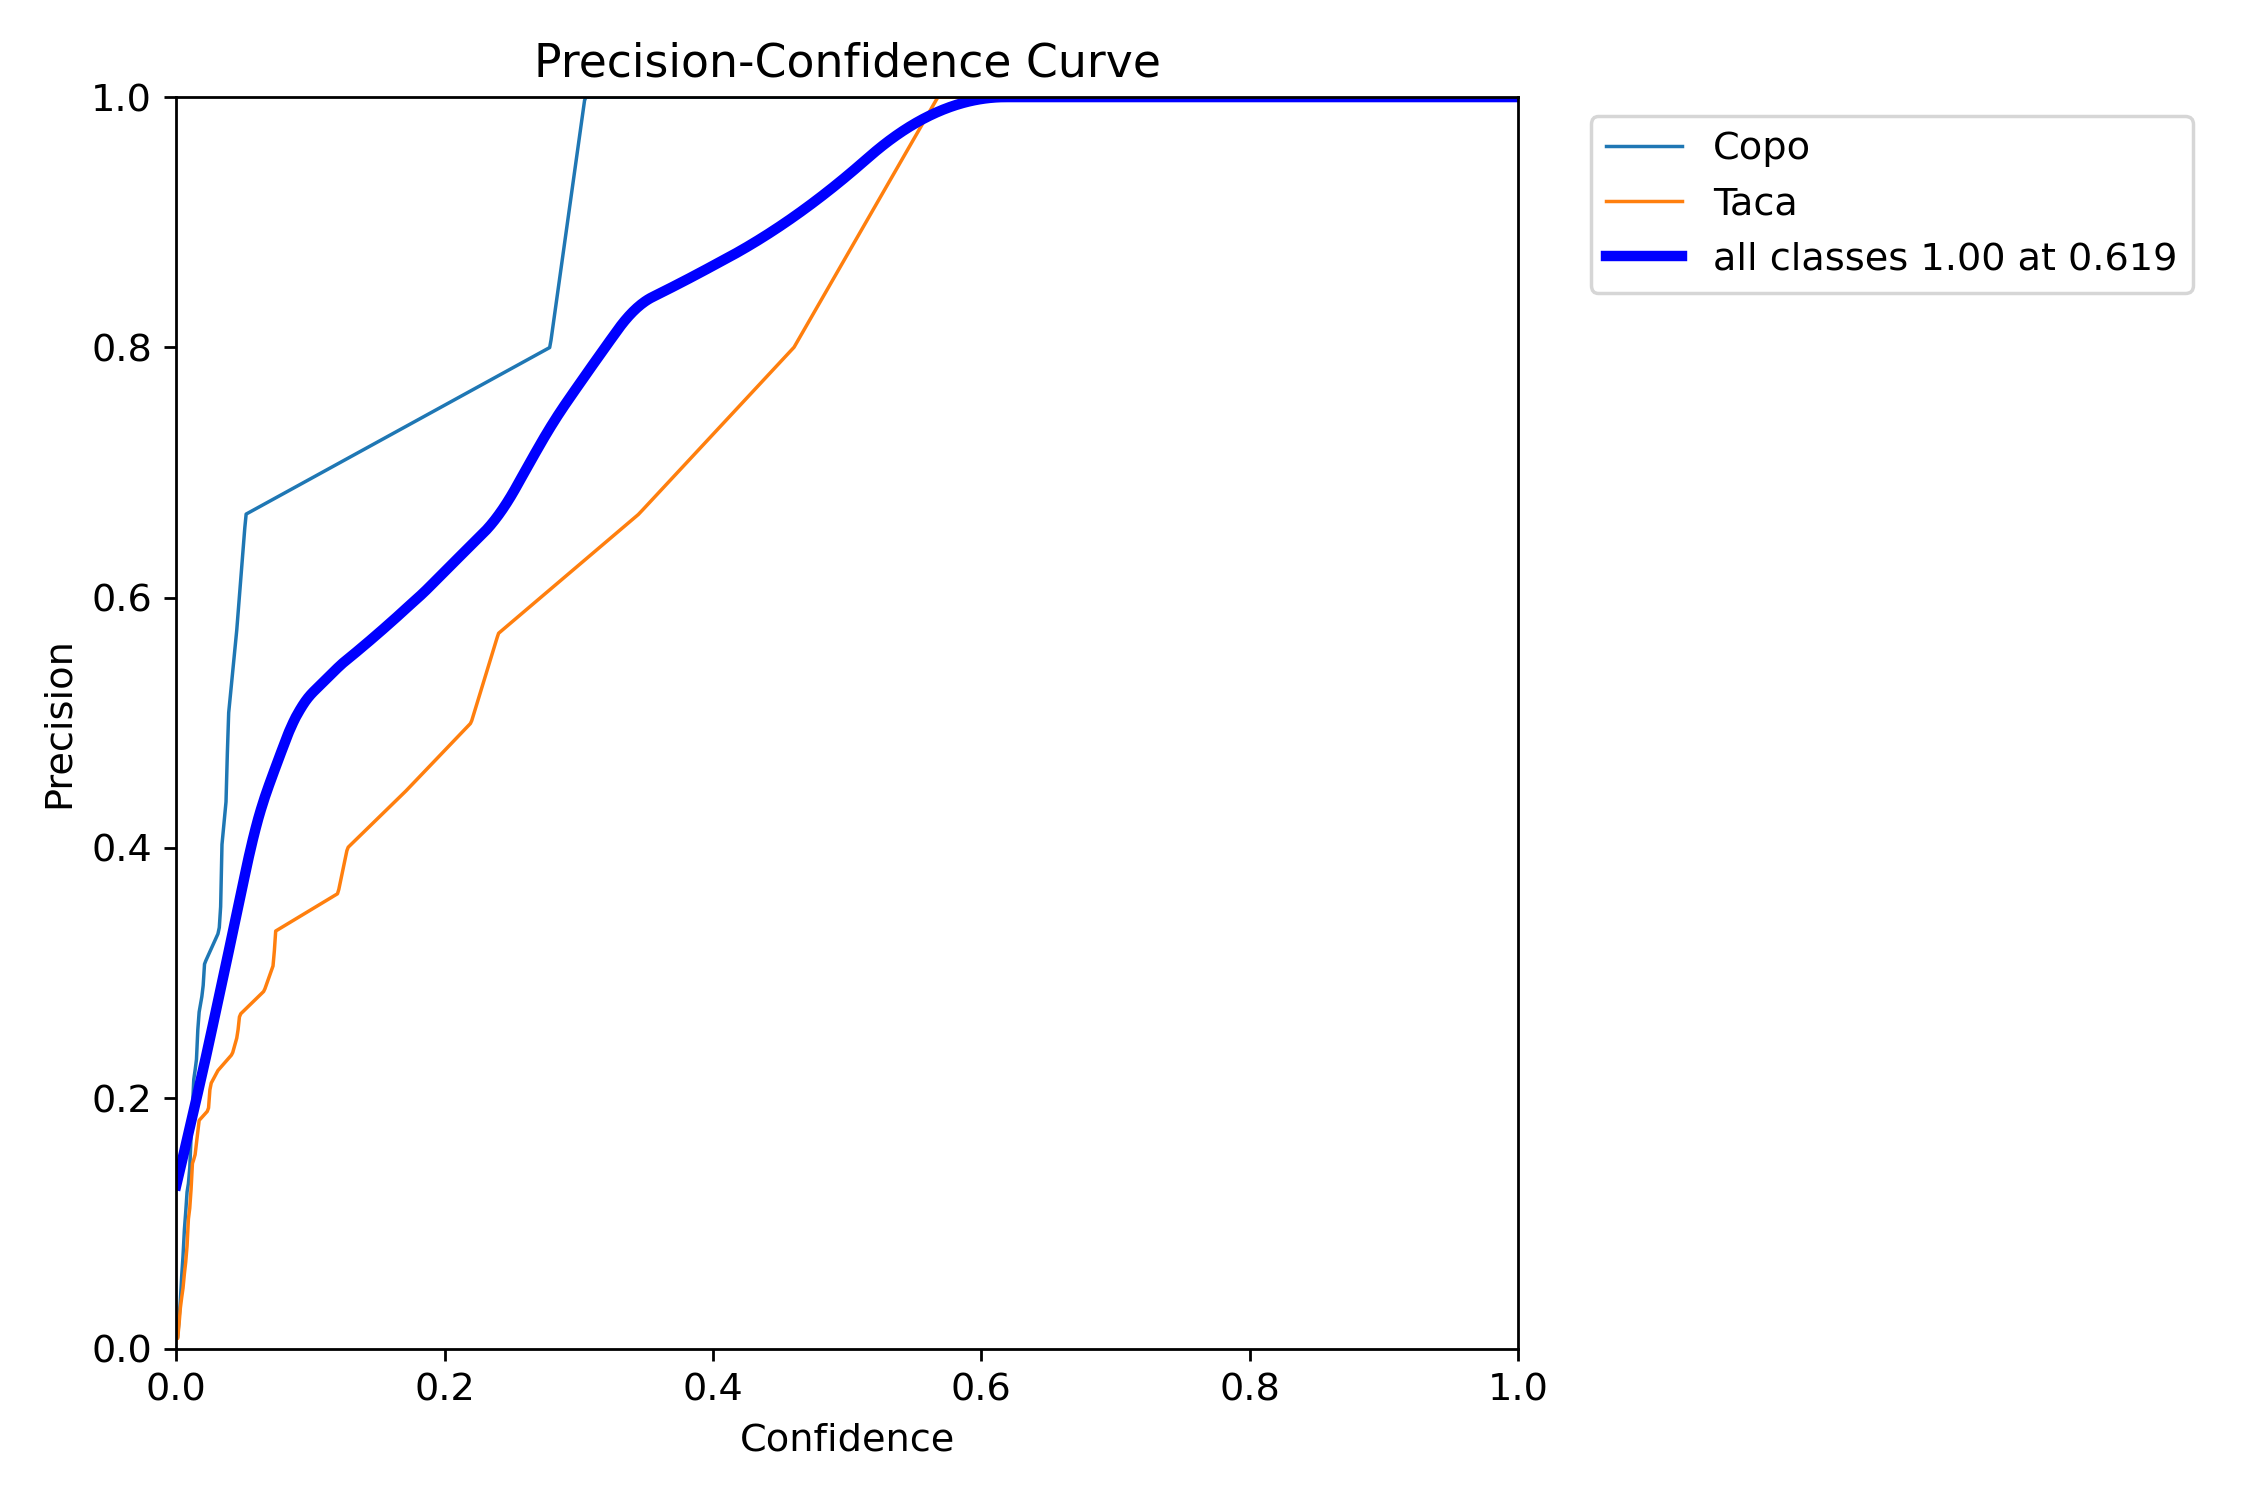

R_curve.png


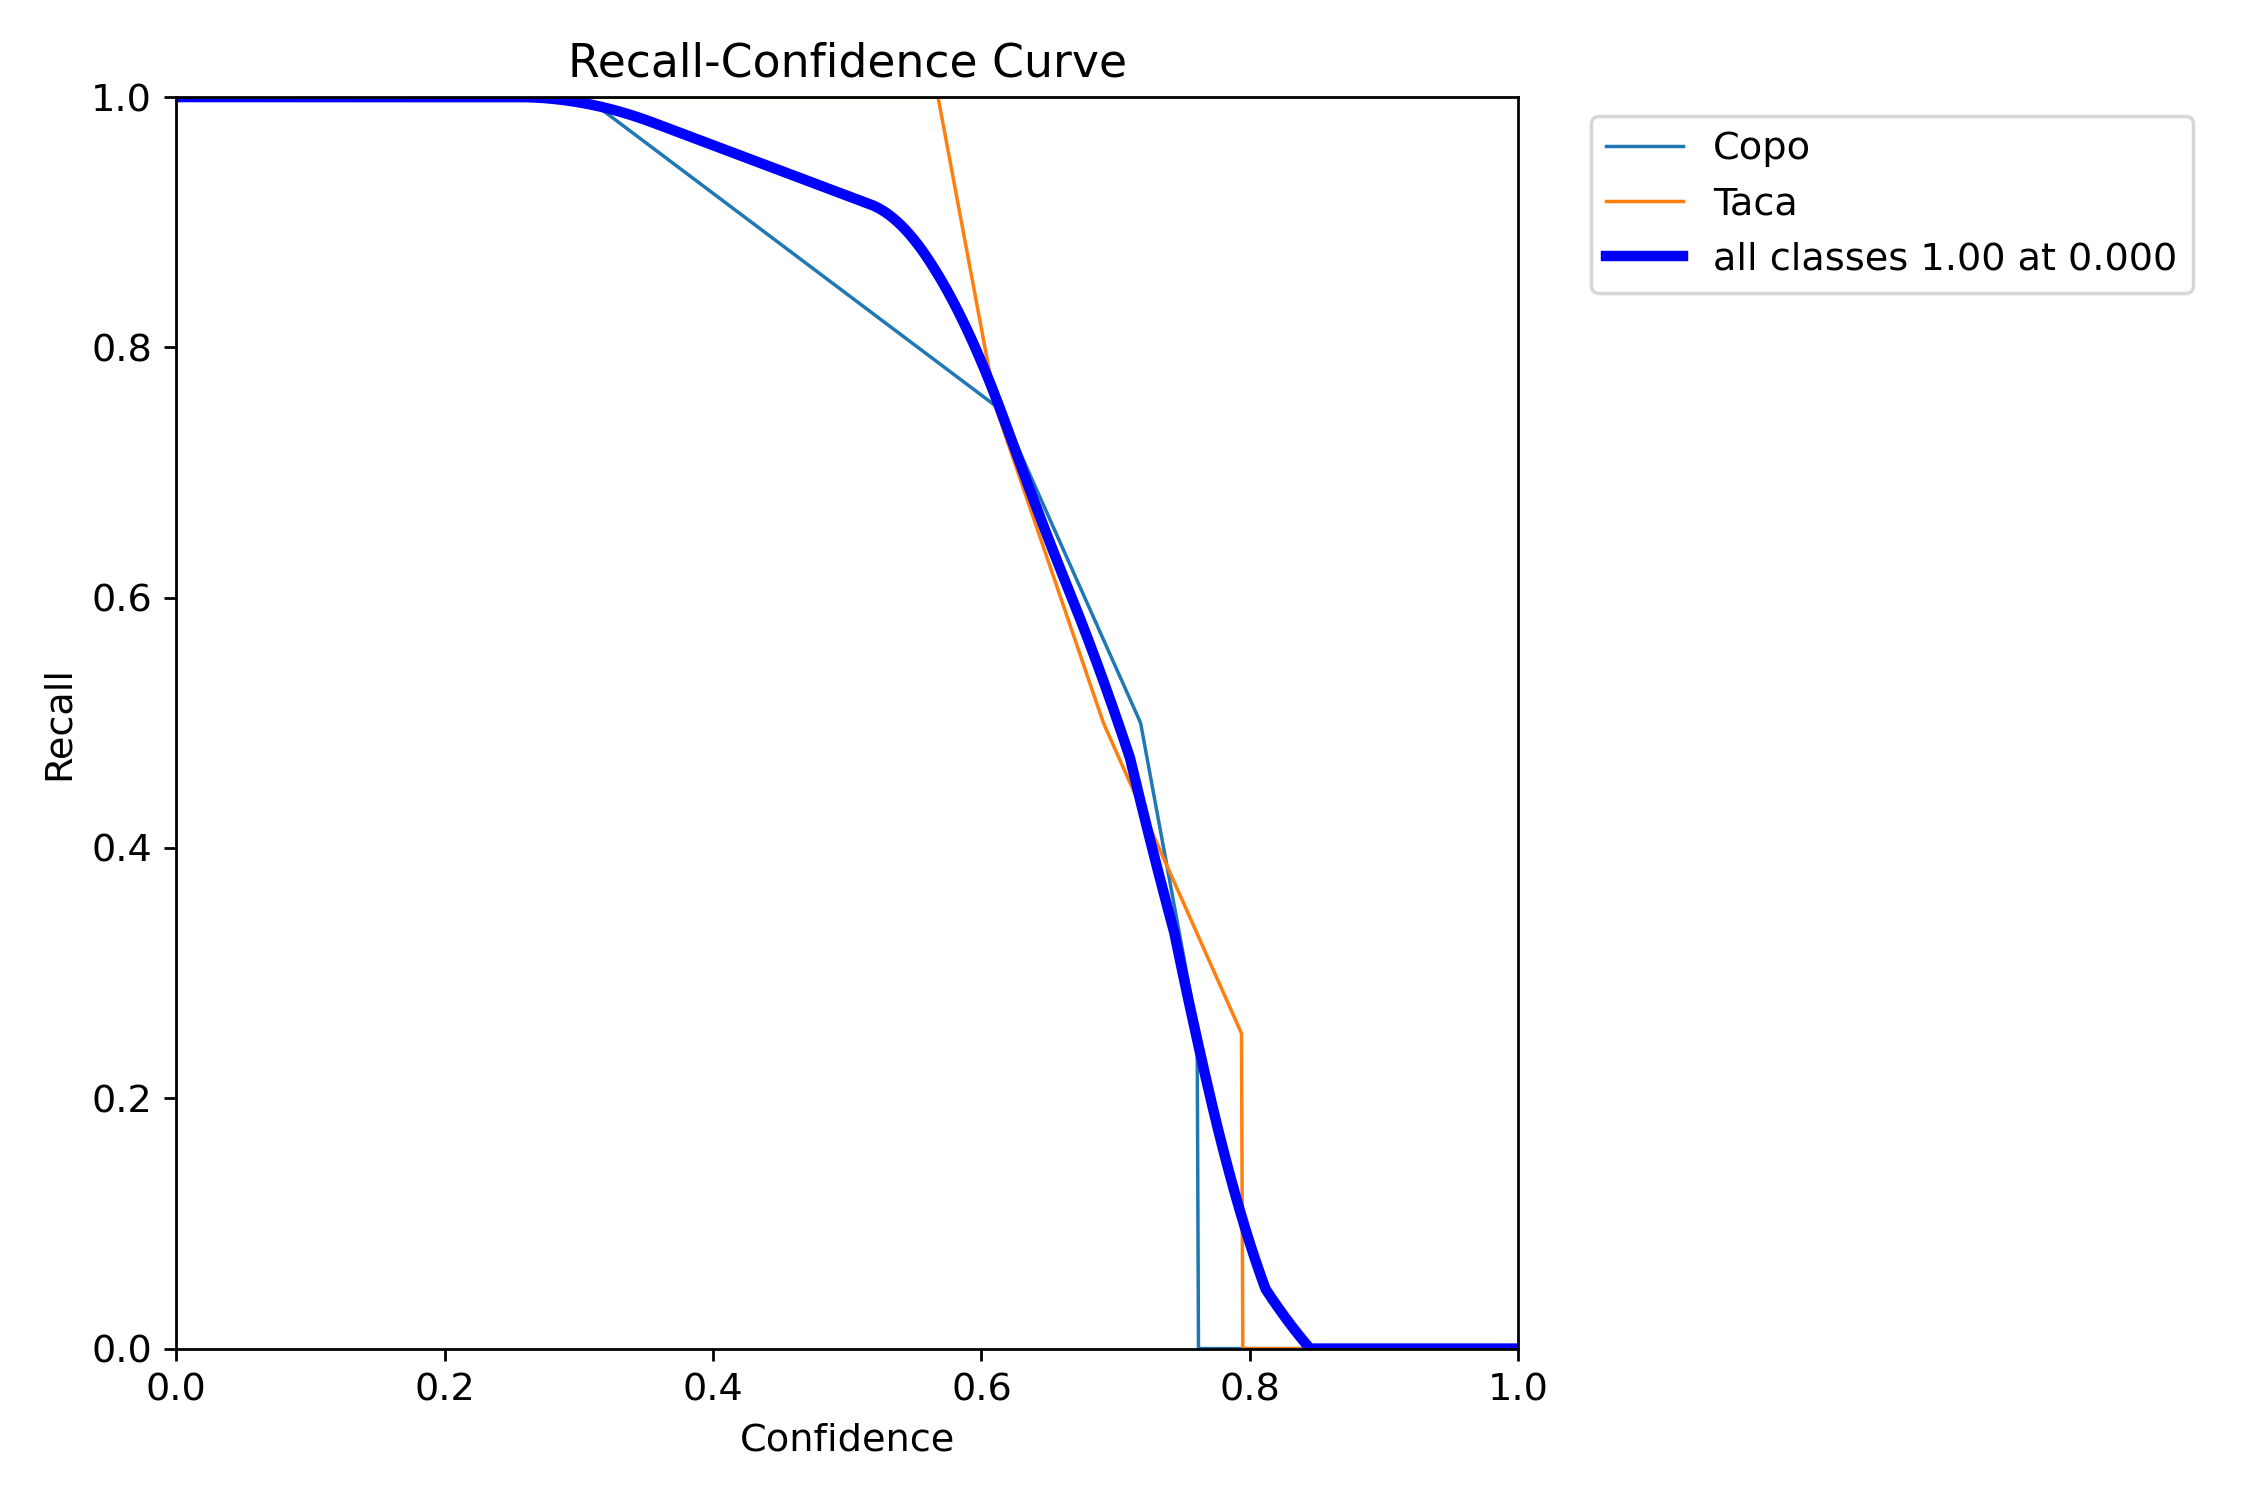

F1_curve.png


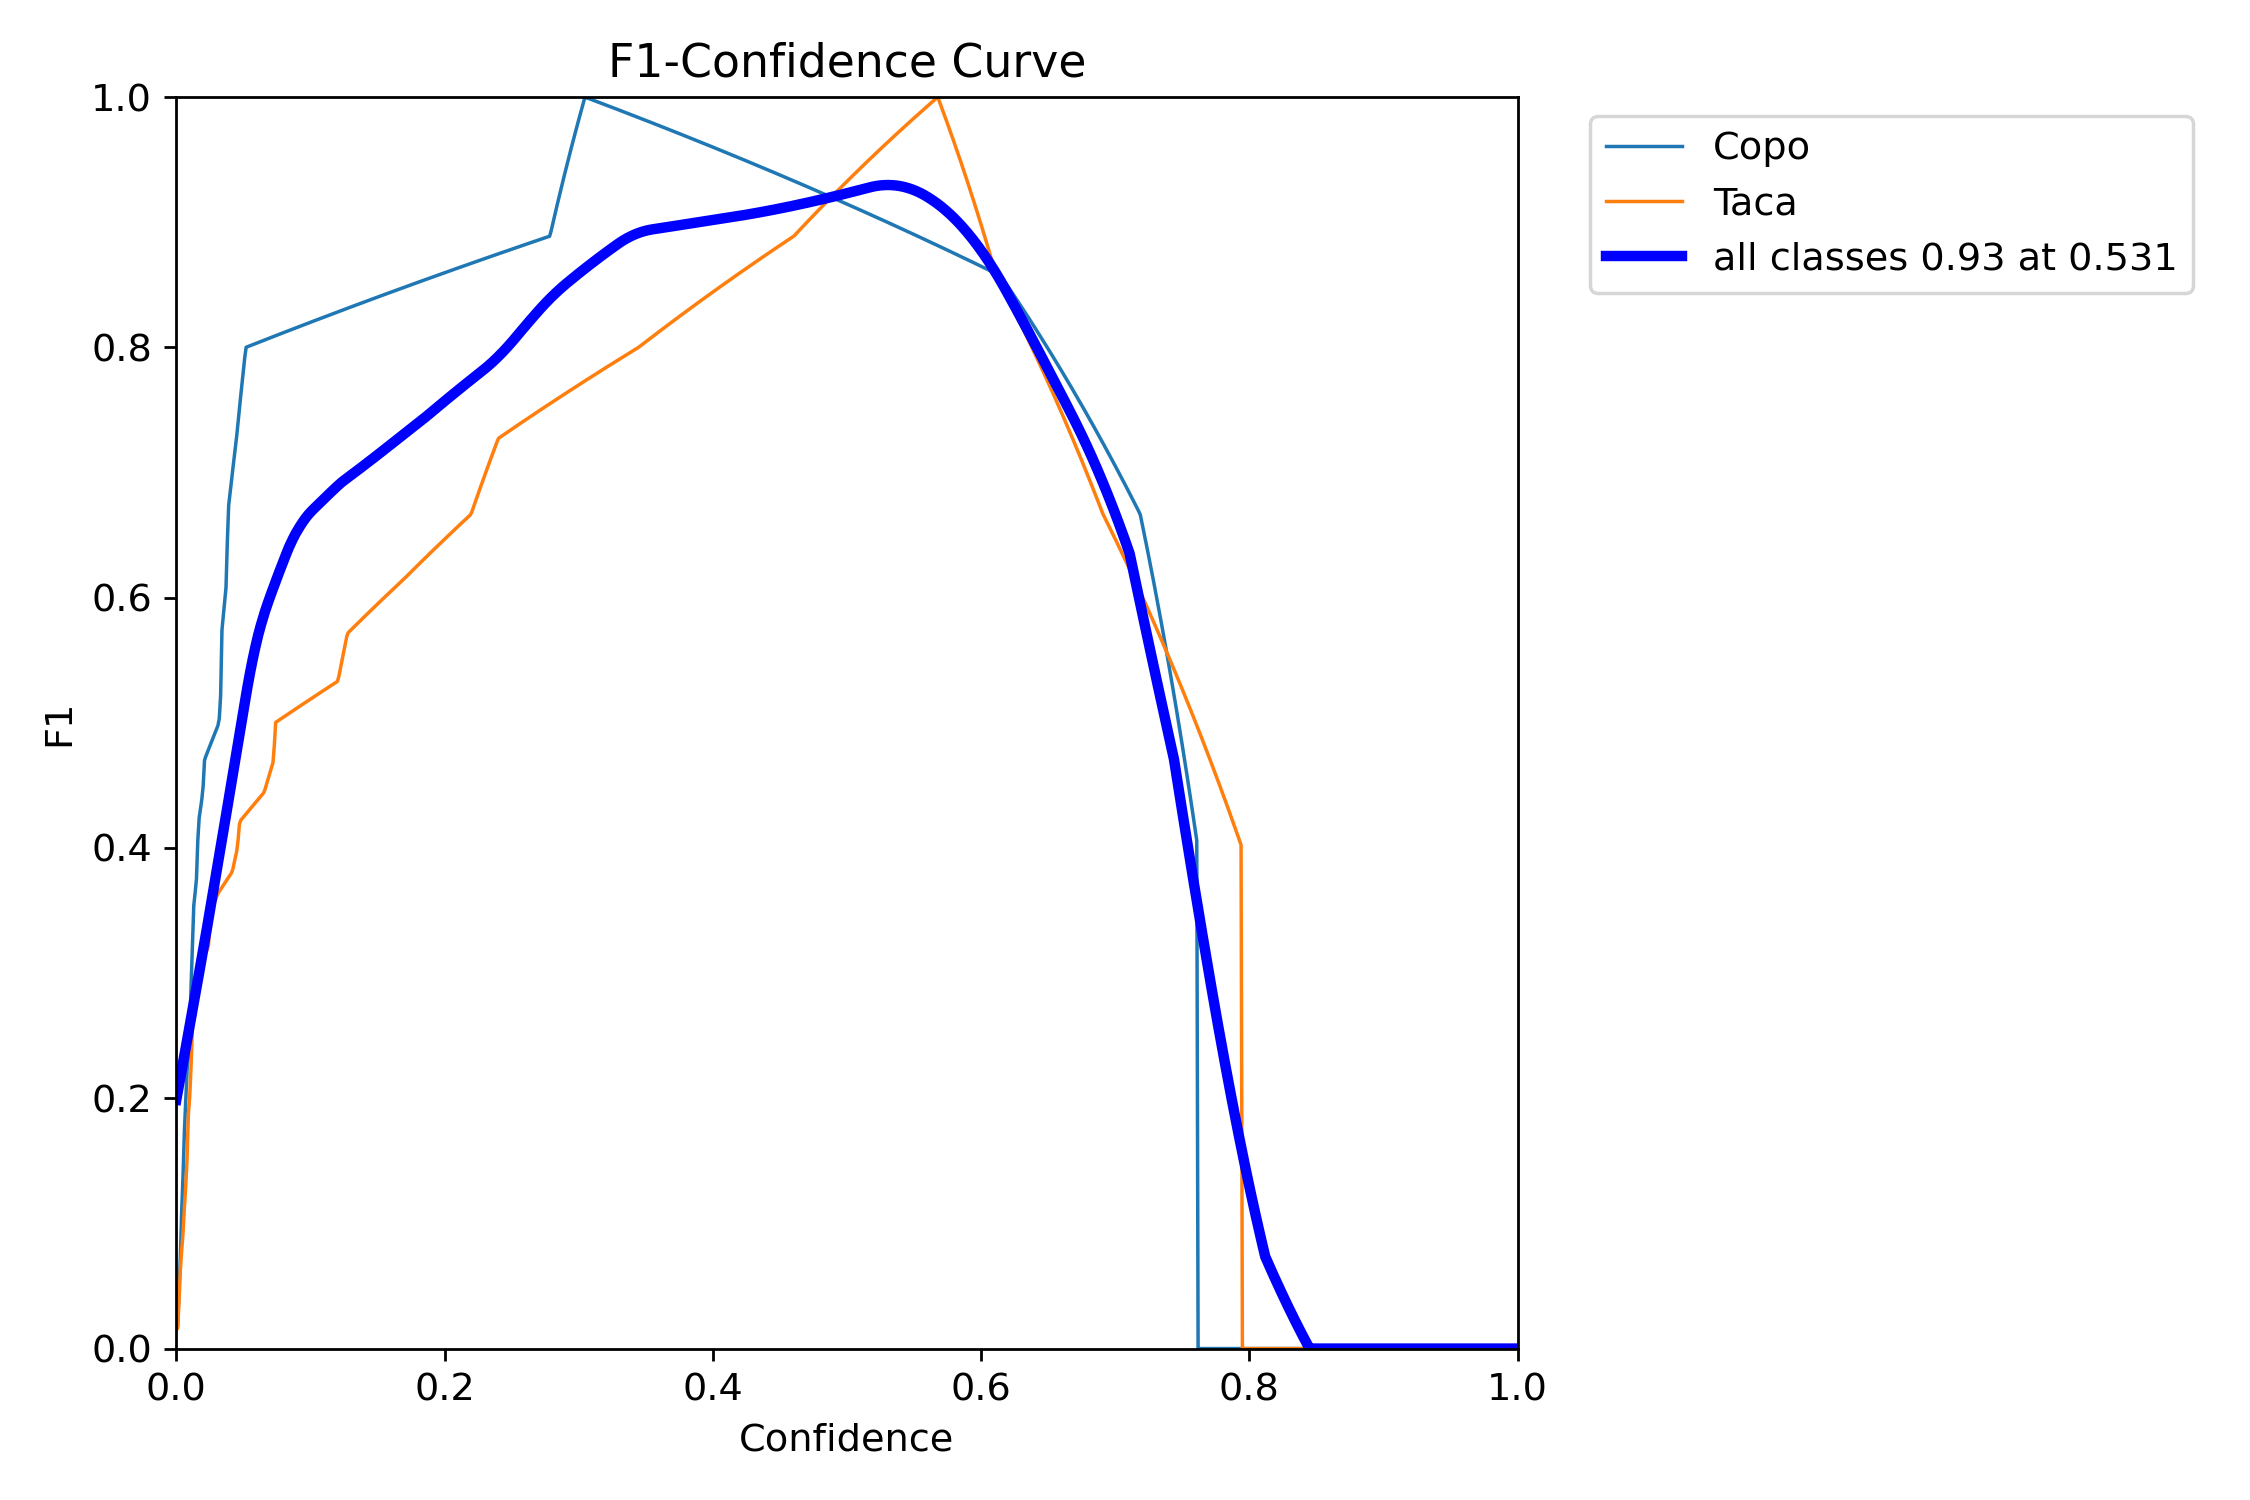

In [14]:
from IPython.display import Image, display
from pathlib import Path

for run in ['validacao_20_epocas', 'validacao_40_epocas']:
    pasta = Path('/content/yolov5/runs/val') / run
    print('\n', run)
    for nome in ['confusion_matrix.png', 'PR_curve.png', 'P_curve.png', 'R_curve.png', 'F1_curve.png']:
        arq = pasta / nome
        if arq.exists():
            print(nome)
            display(Image(filename=str(arq), width=650))

## 12. Inferência dos dois modelos no conjunto de teste

Isso permite comparar visualmente e medir o tempo total de inferência.

In [15]:
def detect_custom(weights, run_name):
    cmd = (
        f'python /content/yolov5/detect.py '
        f'--weights "{weights}" '
        f'--img 640 '
        f'--source "{TEST_PATH}" '
        f'--name "{run_name}" '
        f'--exist-ok '
        f'--save-txt --save-conf'
    )
    return run_command(cmd)

tempo_inferencia_20 = detect_custom(WEIGHTS_20, 'teste_custom_20')
tempo_inferencia_40 = detect_custom(WEIGHTS_40, 'teste_custom_40')

print('Inferência 20 épocas:', tempo_inferencia_20, 's')
print('Inferência 40 épocas:', tempo_inferencia_40, 's')

python /content/yolov5/detect.py --weights "/content/yolov5/runs/train/experimento_20_epocas/weights/best.pt" --img 640 --source "/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/test" --name "teste_custom_20" --exist-ok --save-txt --save-conf
python /content/yolov5/detect.py --weights "/content/yolov5/runs/train/experimento_40_epocas/weights/best.pt" --img 640 --source "/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/test" --name "teste_custom_40" --exist-ok --save-txt --save-conf
Inferência 20 épocas: 18.923583726999823 s
Inferência 40 épocas: 8.998682114000076 s


# PARTE B — YOLO PRÉ-TREINADA SEM CUSTOMIZAÇÃO

## 13. Teste com `yolov5s.pt`

Aqui usamos a YOLO original treinada no dataset COCO, **sem treinamento nas duas classes da equipe**.

Isso é diferente de utilizar `yolov5s.pt` como peso inicial da YOLO customizada.

O objetivo é observar o que um modelo genérico consegue reconhecer nas mesmas imagens de teste.

In [16]:
cmd_pre = (
    f'python /content/yolov5/detect.py '
    f'--weights yolov5s.pt '
    f'--img 640 '
    f'--source "{TEST_PATH}" '
    f'--name teste_yolo_pre_treinada '
    f'--exist-ok '
    f'--save-txt --save-conf'
)

tempo_inferencia_pre = run_command(cmd_pre)
print(f'Tempo total de inferência YOLO pré-treinada: {tempo_inferencia_pre:.2f} s')

python /content/yolov5/detect.py --weights yolov5s.pt --img 640 --source "/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/RedeNeuralYolo/test" --name teste_yolo_pre_treinada --exist-ok --save-txt --save-conf
Tempo total de inferência YOLO pré-treinada: 7.98 s


### Observação para a análise

A YOLO pré-treinada reconhece apenas as classes existentes no COCO. Portanto, ela pode:
- reconhecer um objeto usando uma classe semanticamente próxima;
- não reconhecer uma das classes do trabalho;
- reconhecer objetos adicionais existentes na cena.

Essa limitação deve ser discutida na comparação final.

# PARTE C — CNN CRIADA DO ZERO

## 14. Preparação dos dados para classificação

YOLO é um detector de objetos e usa bounding boxes. Uma CNN de classificação tradicional espera uma imagem associada a uma classe.

Para permitir a execução correta da CNN, criamo um novo dataset com a seguinte etrutura

```
cnn_dataset/
    train/
        Classe0/
        Classe1/
    val/
        Classe0/
        Classe1/
    test/
        Classe0/
        Classe1/
```



In [17]:
import os
import pathlib
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential, layers

# Caminho atualizado usando a estrutura de pastas do seu Google Drive
path = Path('/content/drive/MyDrive/Cap 1 - O despertar da Rede Neural/CNN')

train_ds = tf.keras.utils.image_dataset_from_directory(
    str(path / "train"),
    image_size=(150, 150),
    batch_size=32,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    str(path / "val"),
    image_size=(150, 150),
    batch_size=32,
    shuffle=False
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    str(path / "test"),
    image_size=(150, 150),
    batch_size=32,
    shuffle=False
)

Found 101 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 36 files belonging to 2 classes.


## 15. Inspeção rápida do Dataset

Inspecionamos o primeiro lote (*batch*) do conjunto de treinamento para garantir que os tensores de imagem e os rótulos estejam no formato correto esperados pela nossa rede.

In [18]:
for image, label in train_ds.take(1):
  print("Dimensões do batch de imagens:", image.shape)
  print("Dimensões do batch de labels:", label.shape)
  print("Labels das imagens do lote:", label.numpy())

Dimensões do batch de imagens: (32, 150, 150, 3)
Dimensões do batch de labels: (32,)
Labels das imagens do lote: [1 0 0 0 0 1 0 0 0 0 1 1 0 1 0 0 1 0 0 0 0 1 0 0 1 0 0 1 1 1 1 1]


## 16. Arquitetura da CNN criada do zero

Construímos um modelo sequencial contendo uma camada de reescala de pixels (`Rescaling` para normalizar as cores entre 0 e 1), seguida por uma camada de convolução (`Conv2D`), subamostragem por Max Pooling (`MaxPool2D`), achatamento dos dados (`Flatten`) e camadas densas totalmente conectadas com ativação final Sigmoid para classificação binária.

In [19]:
model = Sequential()
model.add(layers.Rescaling(1./255, input_shape=(150, 150, 3)))
model.add(layers.Conv2D(16, kernel_size=10, activation="relu"))
model.add(layers.MaxPool2D(3))

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(32, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.13/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 17. Compilação do Modelo e Early Stopping

Compilamos o modelo utilizando o otimizador `adam` e a função de perda `binary_crossentropy` (adequada para classificação binária com saída sigmoid). Também configuramos o critério de parada prematura (`EarlyStopping`) para interromper o treino caso o desempenho na validação pare de melhorar.

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

es = EarlyStopping(
    monitor="val_accuracy",
    patience=5,
    restore_best_weights=True
)

## 18. Treinamento da CNN

Realizamos o ajuste do modelo utilizando até 50 épocas, monitorando o tempo gasto no processamento.

In [21]:
import time

inicio = time.perf_counter()

with tf.device("/device:GPU:0"):
  results = model.fit(
      train_ds,
      epochs=50,
      validation_data=val_ds,
      batch_size=32,
      callbacks=[es]
  )

tempo_treino_cnn = time.perf_counter() - inicio
print(f'Tempo de treinamento da CNN: {tempo_treino_cnn:.2f} s')

Epoch 1/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 47s 9s/step - accuracy: 0.5743 - loss: 0.7784 - val_accuracy: 0.5000 - val_loss: 0.7881
Epoch 2/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 11s 3s/step - accuracy: 0.4851 - loss: 0.7310 - val_accuracy: 0.5625 - val_loss: 0.6818
Epoch 3/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.6634 - loss: 0.6712 - val_accuracy: 0.4375 - val_loss: 0.6902
Epoch 4/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.8812 - loss: 0.6313 - val_accuracy: 0.6250 - val_loss: 0.6689
Epoch 5/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.5446 - loss: 0.7313 - val_accuracy: 0.5000 - val_loss: 0.7397
Epoch 6/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.7822 - loss: 0.5790 - val_accuracy: 0.5625 - val_loss: 0.6709
Epoch 7/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 18s 3s/step - accuracy: 0.8515 - loss: 0.5391 - val_accuracy: 0.7500 - val_loss: 0.6298
Epoch 8/50
4/4 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.8911 - loss: 0.4409 - val_accuracy: 0.4375 - val_loss: 0.7089
Epoch 9/5

## 19. Curvas de Aprendizado e Avaliação de Resultados

Visualizamos as curvas de acurácia e perda (loss) ao longo do tempo, avaliamos o desempenho final do classificador no conjunto de teste independente e geramos a matriz de confusão correspondente.

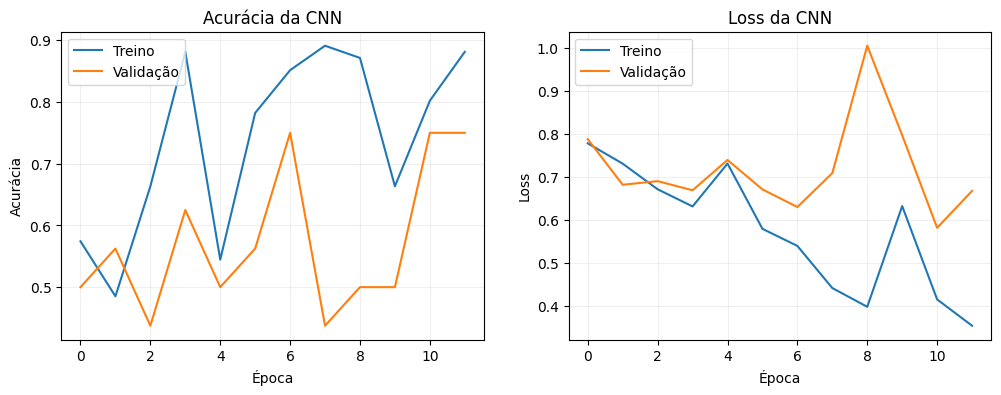

2/2 ━━━━━━━━━━━━━━━━━━━━ 19s 3s/step - accuracy: 0.7222 - loss: 0.6140

Loss no teste: 0.6140
Acurácia no teste: 0.7222
2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 572ms/step


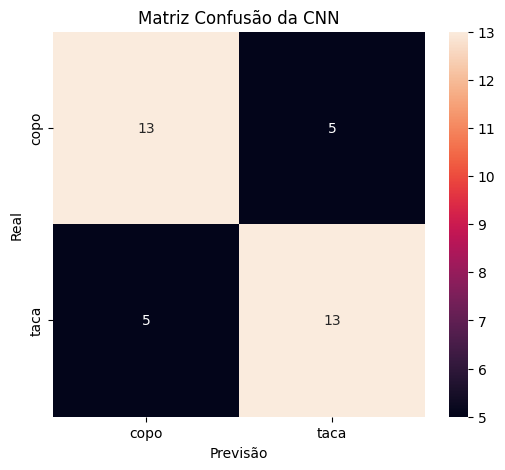

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# 1. Plot das curvas de treinamento
hist = pd.DataFrame(results.history)

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(hist['accuracy'], label='Treino')
plt.plot(hist['val_accuracy'], label='Validação')
plt.title('Acurácia da CNN')
plt.xlabel('Época')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True, alpha=.2)

plt.subplot(1, 2, 2)
plt.plot(hist['loss'], label='Treino')
plt.plot(hist['val_loss'], label='Validação')
plt.title('Loss da CNN')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=.2)
plt.show()

# 2. Avaliação no conjunto de teste
loss_val, acc_val = model.evaluate(test_ds)
print(f"\nLoss no teste: {loss_val:.4f}")
print(f"Acurácia no teste: {acc_val:.4f}")

# 3. Fazer previsões e gerar Matriz de Confusão
preds = model.predict(test_ds)
y_pred = (preds >= 0.5).astype(int).flatten()
y_test = np.concatenate([labels.numpy() for imagens, labels in test_ds])

cf_matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cf_matrix,
    annot=True,
    fmt="d",
    xticklabels=test_ds.class_names,
    yticklabels=test_ds.class_names
)
plt.xlabel("Previsão")
plt.ylabel("Real")
plt.title("Matriz Confusão da CNN")
plt.show()

# PARTE D — COMPARAÇÃO FINAL

## 20. Comparação quantitativa

**Atenção metodológica:** mAP da YOLO e acurácia da CNN não são a mesma métrica.  
YOLO resolve **detecção de objetos**; a CNN criada aqui resolve **classificação dos recortes**.

A tabela deve ser interpretada respeitando essa diferença.

In [23]:
comparacao = pd.DataFrame([
    {
        'abordagem': 'YOLO customizada - 20 épocas',
        'treinada_nas_classes_do_trabalho': 'Sim',
        'metrica_principal': 'mAP@0.5',
        'resultado': resumo_yolo.loc[0, 'mAP50_max'] if 'resumo_yolo' in locals() and not resumo_yolo.empty else None,
        'tempo_treino_s': tempo_treino_20 if 'tempo_treino_20' in locals() else None,
        'tempo_inferencia_teste_s': tempo_inferencia_20 if 'tempo_inferencia_20' in locals() else None,
        'observacao': 'Detector customizado'
    },
    {
        'abordagem': 'YOLO customizada - 40 épocas',
        'treinada_nas_classes_do_trabalho': 'Sim',
        'metrica_principal': 'mAP@0.5',
        'resultado': resumo_yolo.loc[1, 'mAP50_max'] if 'resumo_yolo' in locals() and len(resumo_yolo) > 1 else None,
        'tempo_treino_s': tempo_treino_40 if 'tempo_treino_40' in locals() else None,
        'tempo_inferencia_teste_s': tempo_inferencia_40 if 'tempo_inferencia_40' in locals() else None,
        'observacao': 'Detector customizado'
    },
    {
        'abordagem': 'YOLOv5s pré-treinada (COCO)',
        'treinada_nas_classes_do_trabalho': 'Não',
        'metrica_principal': 'Análise qualitativa',
        'resultado': None,
        'tempo_treino_s': 0,
        'tempo_inferencia_teste_s': tempo_inferencia_pre if 'tempo_inferencia_pre' in locals() else None,
        'observacao': 'Modelo genérico; classes limitadas ao COCO'
    },
    {
        'abordagem': 'CNN criada do zero',
        'treinada_nas_classes_do_trabalho': 'Sim',
        'metrica_principal': 'Acurácia',
        'resultado': acc_val if 'acc_val' in locals() else None,
        'tempo_treino_s': tempo_treino_cnn if 'tempo_treino_cnn' in locals() else None,
        'tempo_inferencia_teste_s': None,
        'observacao': 'Classificação direta dos conjuntos de imagem'
    }
])

display(comparacao)

,abordagem,treinada_nas_classes_do_trabalho,metrica_principal,resultado,tempo_treino_s,tempo_inferencia_teste_s,observacao
0,YOLO customizada - 20 épocas,Sim,mAP@0.5,0.782500,1068.223689,18.923584,Detector customizado
1,YOLO customizada - 40 épocas,Sim,mAP@0.5,0.995000,1987.353620,8.998682,Detector customizado
2,YOLOv5s pré-treinada (COCO),Não,Análise qualitativa,NaN,0.000000,7.984504,Modelo genérico; classes limitadas ao COCO
3,CNN criada do zero,Sim,Acurácia,0.722222,212.217982,NaN,Classificação direta dos conjuntos de imagem


## 21. Comparação qualitativa

Preencha/complemente a análise após executar o notebook:

| Abordagem | Vantagens | Limitações | Facilidade de integração |
|---|---|---|---|
| YOLO customizada — 20 épocas | Treinamento mais rápido; detecta e localiza os objetos | Pode ter menor convergência que um treino mais longo | Alta |
| YOLO customizada — 40 épocas | Melhor desempenho entre todos os outros modelos | Treinamento mais demorado  | Alta |
| YOLOv5s pré-treinada | Não exige novo treinamento | Limitada às classes do COCO; pode não representar as classes do projeto | Muito alta |
| CNN do zero | Arquitetura simples e controlada pela equipe | Como é treinada manualmente, é demorado achar os melhores parâmetros | Alta |



# 22. Conclusão

Após a execução completa, substitua os campos entre colchetes pelos valores obtidos.

**Modelo de conclusão:**

Foram avaliadas três abordagens de visão computacional: uma YOLOv5 customizada em dois regimes de treinamento (20 e 40 épocas), uma YOLOv5s pré-treinada no COCO sem customização e uma CNN construída do zero.

No treinamento customizado, o experimento de **20 épocas** apresentou mAP@0.5 de **[0.78]**, enquanto o experimento de **40 épocas** apresentou **[0.99]**. O tempo de treinamento foi de aproximadamente **[17 minutos]** e **[33 minutos]**, respectivamente. Esses resultados mostram que quanto mais épocas, maioro tempo de treinamento. Entretanto, se dividirmos a métrica pelo tempo treinado, obtemos a seguinte informação, a grosso modo:
20 épocas: Cada minuto aumentou apx. 0,046 da métrica
40 épocas: Cada minuto aumentou apx. 0,030 da métrica
logo, um minuto do primeiro modelo rendeu mais doque o minuto do segundo modelo

A YOLO pré-treinada foi executada diretamente sobre as imagens de teste. Como ela foi treinada no conjunto COCO e não especificamente nas classes escolhidas neste trabalho, não foi possível analisar especificamente seu desempenho por meio de uma métrica numérica.

A CNN criada do zero obteve acurácia de teste de **[72%]**. Diferentemente da YOLO, ela foi utilizada como classificador dos objetos recortados a partir das anotações, não como detector completo.

Considerando os resultados observados, o Yolo customizado treinado por 40 épocas foi o mais efetivo para a tarefa. Não só obteve resultado excelentes, mas também o tempo, quando levado em consideração o custo/benefício, foi o melhor.

A comparação evidencia que a escolha da arquitetura depende do problema: modelos de detecção como YOLO fornecem classe e localização do objeto, enquanto uma CNN classificadora convencional é adequada quando o objeto já está isolado na imagem.